# Apartment Sale Listings Analysis

You have access to data from the Yandex Real Estate service — an archive of apartment sale listings in Saint Petersburg and nearby localities over several years. Your task is to learn how to determine the market value of real estate properties. To do this, perform exploratory data analysis and identify the parameters that influence property prices. This will enable the creation of an automated system to detect anomalies and fraudulent activities.

Each apartment listing contains two types of data. The first is provided by the user, and the second is automatically generated based on cartographic data. For example, distances to the city center, airport, and other locations are obtained automatically from geolocation services. The number of nearby parks and bodies of water is also filled in without user input.

### Open the data file and examine the general information

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r'C:\Users\Vera\Documents\PET Projects\Portfolio\Data Analyst Practicum\eng\datasets\real_estate_data.csv', sep='\t')

In [3]:
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

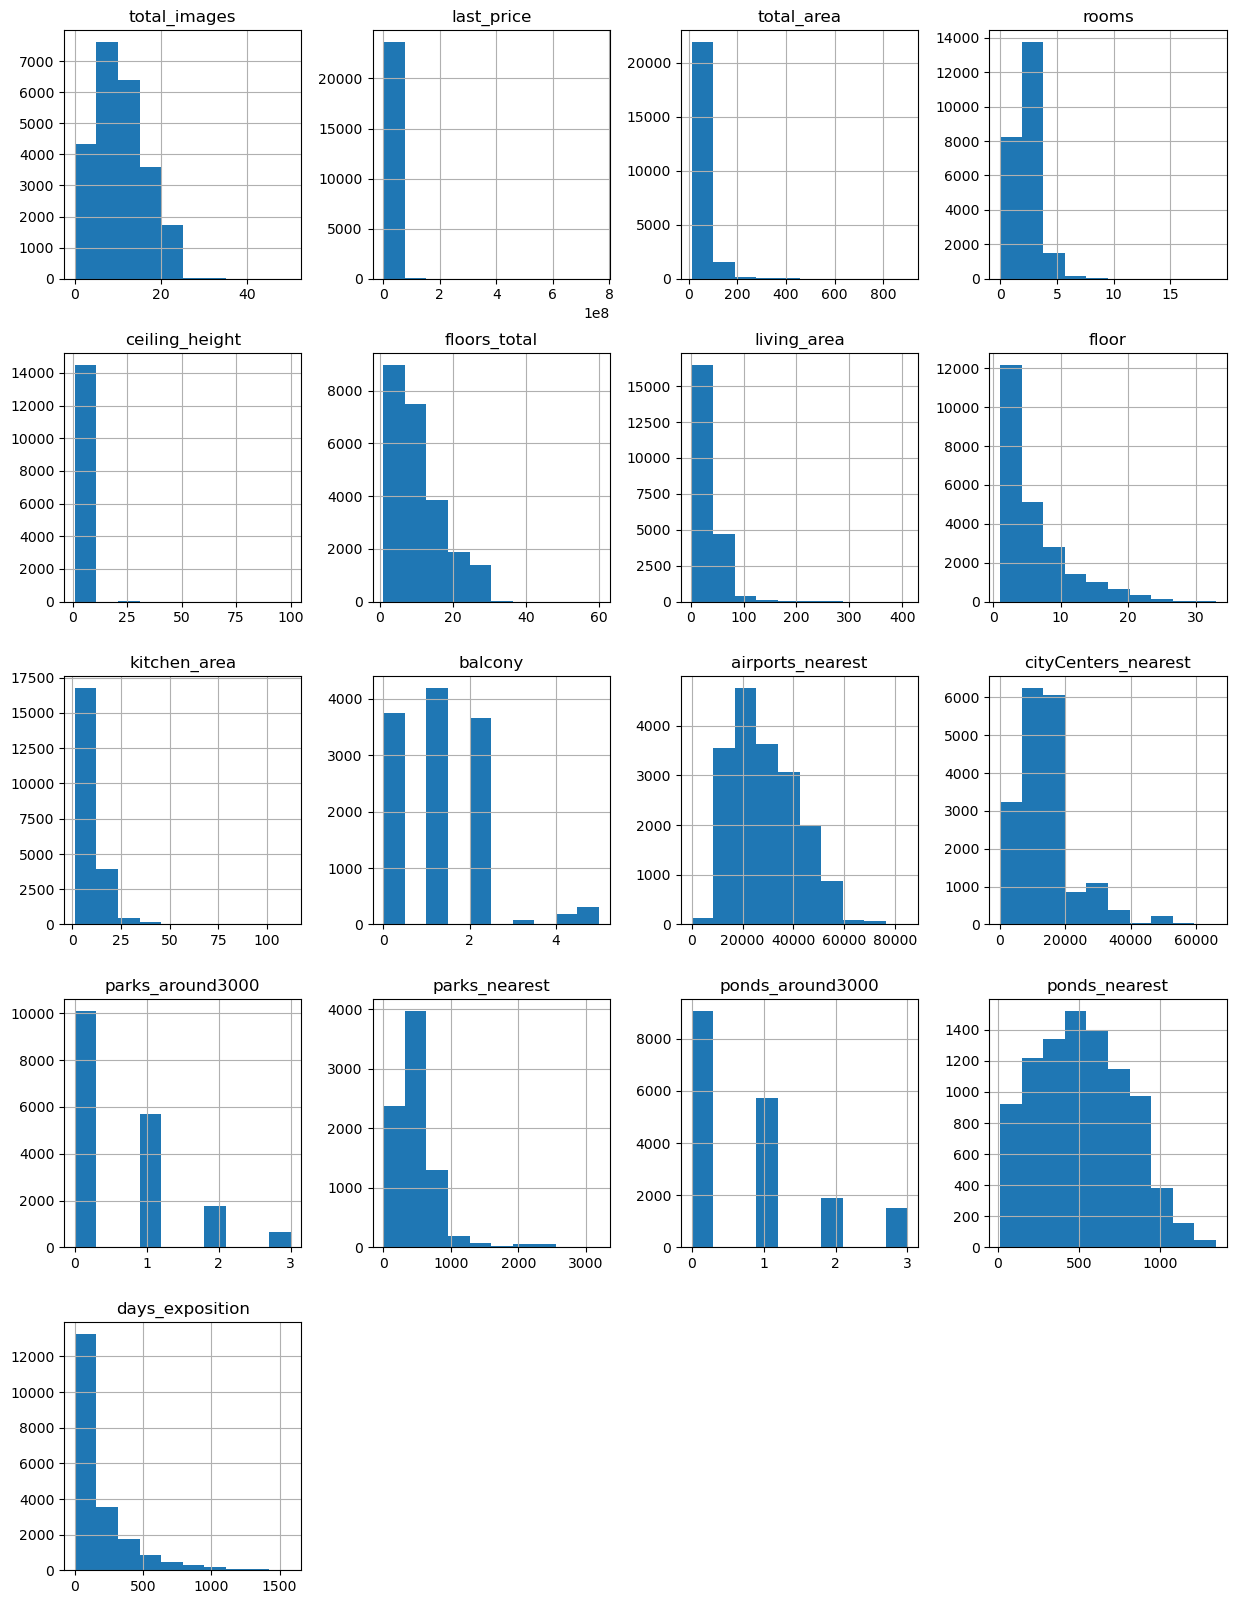

In [5]:
data.hist(figsize=(15, 20));

In [6]:
data.duplicated().sum() # display the number of duplicate rows in the data

0

After the initial review of the dataset, which contains archived apartment sale listings from the Yandex Real Estate service, the following conclusions can be made:

**Data Quality:** Missing values were found (in both user-entered columns and those automatically generated). Handling these missing values will be a crucial part of the data preprocessing stage.

**Duplicates:** A check for obvious duplicate entries was performed, and no exact duplicate rows were found.

### Data preprocessing

#### Renaming Columns  
The column names `'parks_around3000'`, `'ponds_around3000'`, and `'cityCenters_nearest'` should be converted to a consistent style (snake_case):

In [7]:
data = data.rename(
    columns={'parks_around3000':'parks_around_3000', 
             'ponds_around3000':'ponds_around_3000', 
             'cityCenters_nearest':'city_centers_nearest'}
)

# Check:
data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'city_centers_nearest',
       'parks_around_3000', 'parks_nearest', 'ponds_around_3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

#### Missing values


In [8]:
def pass_value_barh(df):
    try:
        (
            (df.isna().mean() * 100)
            .to_frame()
            .rename(columns={0: 'space'})
            .query('space > 0')
            .sort_values(by='space', ascending=True)
            .plot(kind='barh', figsize=(19, 6), rot=0, legend=False, fontsize=16)
            .set_title('Missing values' + "\n", fontsize=22, color='SteelBlue')
        )
    except:
        print('No missing values left :) or an error occurred in the first part of the function')


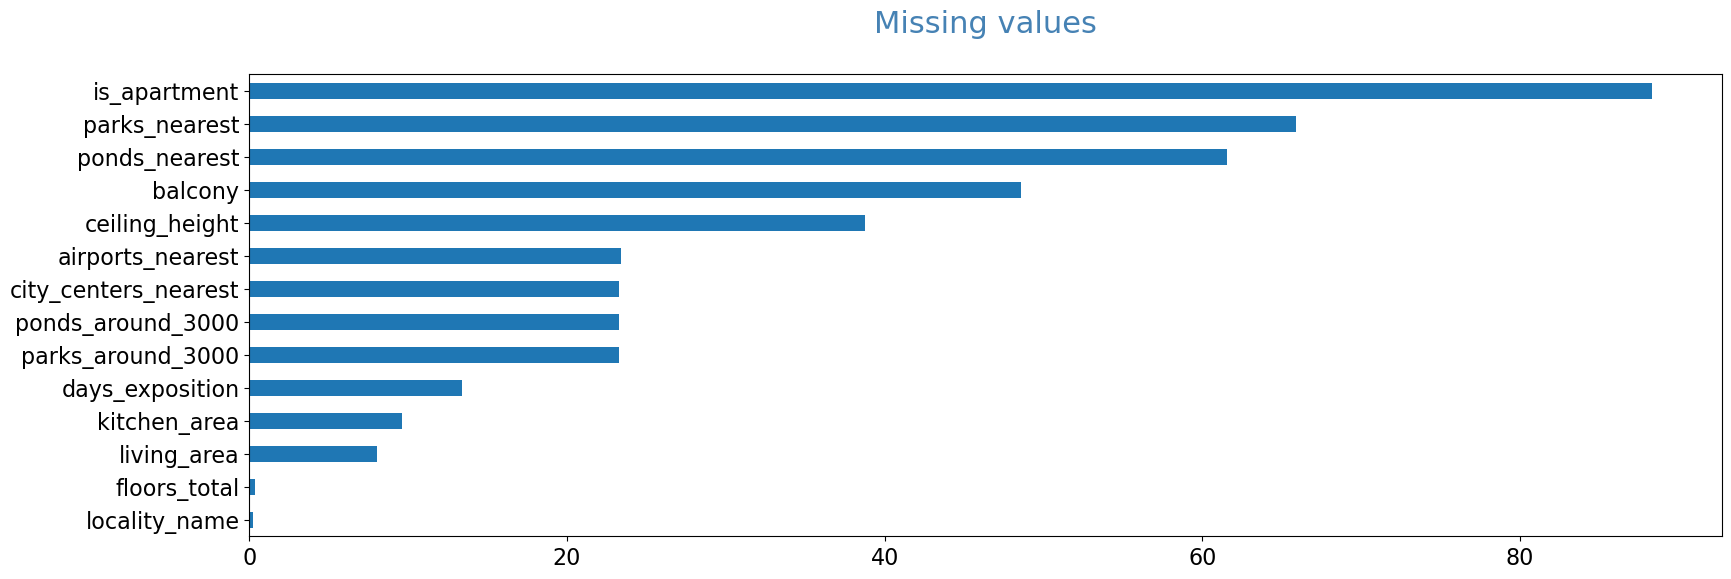

In [9]:
pass_value_barh(data)

In [10]:
print(data.isna().sum()) # display the number of missing values for each column

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around_3000        5518
parks_nearest           15620
ponds_around_3000        5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


Missing values in any column can occur if the seller considers the information irrelevant, does not want to provide it, forgets to fill it in, or due to technical aspects of data collection and processing.

##### Columns `'balcony'`, `'parks_around_3000'`, and `'ponds_around_3000'`:  
The `'balcony'` column (presence and number of balconies): Most likely, missing values mean that the apartment does not have a balcony. These missing values can be replaced with 0.

The `'balcony'`, `'parks_around_3000'`, and `'ponds_around_3000'` columns (number of parks and bodies of water within a 3 km radius): Missing values in these columns can be interpreted as the absence of parks or bodies of water within the specified radius and replaced with 0.

In [11]:
data['balcony'] = data['balcony'].fillna(0)
data['parks_around_3000'] = data['parks_around_3000'].fillna(0)
data['ponds_around_3000'] = data['ponds_around_3000'].fillna(0)

##### The 'ceiling_height' column
We examine the 'ceiling_height' column, which represents the ceiling height. We replace missing values with the median value because, if the ceiling height is not specified, it is likely either a standard height or the seller does not know the exact measurements.

In [12]:
# add a column with the distance to the city center in kilometers
data['distance_to_center_km'] = (data['city_centers_nearest'] / 1000).round()

# filter apartments located in Saint Petersburg
spb_data = data[data['locality_name'] == 'Санкт-Петербург']

# calculate the median ceiling height for each distance (in km) in Saint Petersburg
median_ceilings = spb_data.groupby('distance_to_center_km')['ceiling_height'].median()

# add a column with the median values to spb_data for later use
spb_data = spb_data.merge(median_ceilings.rename('median_ceiling_height'), on='distance_to_center_km', how='left')

# fill missing ceiling height values using the median values
spb_data.loc[spb_data['ceiling_height'].isna(), 'ceiling_height'] = spb_data['median_ceiling_height']

# update the main DataFrame with the modified ceiling height values
data.update(spb_data[['ceiling_height']])


In [13]:
print(f'''Number of missing ceiling height values in Saint Petersburg after processing: {data[data['locality_name'] == 'Санкт-Петербург']['ceiling_height'].isna().sum()}''')
print(f'''Total sum of ceiling height values in Saint Petersburg: {data[data['locality_name'] == 'Санкт-Петербург']['ceiling_height'].sum()}''')


Number of missing ceiling height values in Saint Petersburg after processing: 1904
Total sum of ceiling height values in Saint Petersburg: 38605.745


In [14]:
# Other missing values (not for Saint Petersburg) are filled in with the median 
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())

##### Column 'is_apartment'
We are examining the `'is_apartment'` column (whether the property is an apartment-style unit). Missing values here can be replaced with `False`. Most likely, sellers leave this field blank when creating listings, which explains the high number of missing values (the majority of properties are regular apartments, not apartment-style units).

In [162]:
data['is_apartment'] = data['is_apartment'].fillna(False).astype(bool)

##### Column 'floors_total'  
There are only 85 missing values in this column. These rows will be removed.

In [16]:
data = data.dropna(subset=['floors_total'])

##### 'living_area' and 'kitchen_area' columns

In [17]:
# create a variable without missing values in the 'living_area' column
nan_living_area = data[['total_area', 'living_area']].dropna(subset=['living_area'])

# create a new column containing the ratio of living area to total area
nan_living_area['part'] = nan_living_area['living_area'] / nan_living_area['total_area']

# fill missing values in 'living_area' using total area multiplied by the median living area ratio
data['living_area'] = data['living_area'].fillna(data['total_area'] * nan_living_area['part'].median()).astype('int')

# same procedure for 'kitchen_area'
nan_living_area = data[['total_area', 'kitchen_area']].dropna(subset=['kitchen_area'])
nan_living_area['part'] = nan_living_area['kitchen_area'] / nan_living_area['total_area']
data['kitchen_area'] = data['kitchen_area'].fillna(data['total_area'] * nan_living_area['part'].median()).astype('int')


In [18]:
len(data.query('total_area * 0.9 <= (living_area + kitchen_area)'))

572

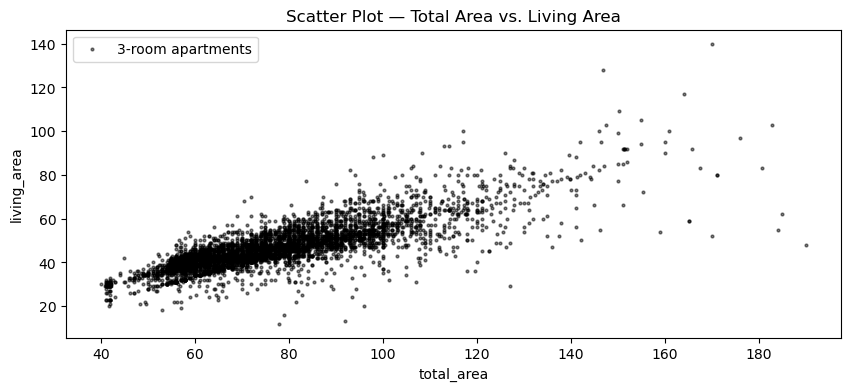

In [19]:
data[data['rooms'] == 3] \
    .query('total_area < 201 and last_price < 25_000_000') \
    .plot(
        kind='scatter',
        y='living_area',
        x='total_area',
        alpha=0.5,
        figsize=(10, 4),
        c='black',
        s=4,
        label='3-room apartments'
    )
plt.title('Scatter Plot — Total Area vs. Living Area')
plt.legend();


##### Column 'locality_name' 
This column contains the names of localities. It might be better to exclude the rows with missing values, as they represent an insignificant portion (49 entries), and this parameter strongly influences property prices. Possible reasons for the missing values include technical issues, human error, or properties located outside official localities.

In [20]:
data = data.dropna(subset=['locality_name'])

Eliminating near duplicates in locality names.
Looking at unique values for 'locality_name'

In [21]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

We eliminate near duplicates in locality names by removing unnecessary words from the locality names.  
We check to make sure everything worked correctly.

In [22]:
# The function takes as input a list of incorrect words and a string with the correct value
def replace_wrong_words(wrong_words, correct_symbol):
    for wrong_word in wrong_words:
        # Create a regular expression pattern to remove the word, considering possible spaces before and after
        regex_pattern = r'\b' + wrong_word + r'\b'
        # Use regex=True to search using the pattern and replace with correct_symbol
        data['locality_name'] = data['locality_name'].str.replace(regex_pattern, correct_symbol, regex=True)
    # After removing all the words, strip any extra spaces at the beginning and end of the string
    data['locality_name'] = data['locality_name'].str.strip()
    
    
duplicates = ['коттеджный', 'городской', 'городского', 'типа', 'поселок', 'посёлок', 
              'деревня', 'село', 'садовое', 'товарищество', 'при', 'железнодорожной', 
              'станции', 'садоводческое', 'некоммерческое']  # list of words to remove from locality names
replace_symbol = ''  # remove the word
replace_wrong_words(duplicates, replace_symbol)  # function call

data['locality_name'].unique()


array(['Санкт-Петербург', 'Шушары', 'Янино-1', 'Парголово', 'Мурино',
       'Ломоносов', 'Сертолово', 'Петергоф', 'Пушкин', 'Кудрово',
       'Коммунар', 'Колпино', 'Красный Бор', 'Гатчина', 'Фёдоровское',
       'Выборг', 'Кронштадт', 'Кировск', 'Новое Девяткино',
       'Металлострой', 'Лебяжье', 'Сиверский', 'Молодцово',
       'Кузьмоловский', 'Новая Ропша', 'Павловск', 'Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'Куттузи', 'Аннино', 'Ефимовский', 'Плодовое', 'Заклинье',
       'Торковичи', 'Первомайское', 'Красное Село', 'Понтонный',
       'Сясьстрой', 'Старая', 'Лесколово', 'Новый Свет', 'Сланцы',
       'Путилово', 'Ивангород', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый Бор', 'Оржицы', 'Кальтино', 'Романовка',
       'Бугры', 'Рощино', 'Кириши', 'Луга', 'Волосово', 'Отрадное',
       'Павлово', 'Оредеж', 'Копорье', 'Молодёжное', 'Тихвин', 'Победа',
       'Нурма', 'Синявино', 'Тосно', 'Стрельна', 'Бокситогорск',

In [23]:
# check
data.locality_name.nunique()

305

In [24]:
# Searching for duplicates by the sum of key parameters:
data[data.duplicated(['total_area', 'floor', 'floors_total', 'rooms', 'locality_name', 
                      'city_centers_nearest', 'parks_nearest', 'ponds_nearest'])]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,distance_to_center_km
1376,6,2500000.0,42.0,2019-03-06T00:00:00,2,2.60,5.0,29,3,False,...,1.0,Выборг,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN
2395,9,1750000.0,44.0,2016-06-09T00:00:00,1,2.60,5.0,18,1,False,...,0.0,Кириши,NaN,NaN,0.0,NaN,0.0,NaN,22.0,NaN
3568,17,4950000.0,58.0,2018-02-20T00:00:00,3,2.50,9.0,39,4,False,...,0.0,Санкт-Петербург,31691.0,12580.0,0.0,NaN,0.0,NaN,264.0,13.0
3576,9,5250000.0,57.1,2015-04-06T00:00:00,3,2.60,9.0,39,8,False,...,1.0,Санкт-Петербург,19816.0,11347.0,0.0,NaN,0.0,NaN,508.0,11.0
4606,12,2900000.0,74.0,2017-12-14T00:00:00,3,2.59,5.0,42,4,False,...,0.0,Выборг,NaN,NaN,0.0,NaN,0.0,NaN,40.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23516,3,22529250.0,139.5,2018-07-04T00:00:00,4,3.30,16.0,82,9,False,...,0.0,Санкт-Петербург,37434.0,8460.0,1.0,441.0,2.0,427.0,266.0,8.0
23541,16,5200000.0,63.0,2017-10-27T00:00:00,3,2.55,12.0,41,4,False,...,0.0,Санкт-Петербург,49631.0,14525.0,2.0,672.0,1.0,172.0,165.0,15.0
23548,14,2250000.0,36.0,2017-10-14T00:00:00,1,2.50,5.0,17,5,False,...,0.0,Выборг,NaN,NaN,0.0,NaN,0.0,NaN,425.0,NaN
23643,1,660000.0,45.0,2019-02-19T00:00:00,2,2.64,5.0,31,4,False,...,1.0,Сланцы,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN


In [25]:
# delete duplicates
data = data.drop_duplicates(subset=['total_area', 'floor', 'floors_total', 'rooms', 'locality_name', 
                                    'city_centers_nearest', 'parks_nearest', 'ponds_nearest'], keep='first')

**airports_nearest, city_centers_nearest, parks_nearest, ponds_nearest (distances to important landmarks and their counts):**  
These missing values can be filled based on median values grouped by locality_name. This information might be omitted by the seller due to lack of precise knowledge or because it is considered non-essential to specify.

In [26]:
# check
data.groupby('locality_name')['city_centers_nearest'].mean()[10:30]

locality_name
Бокситогорск         NaN
Большая Вруда        NaN
Большая Ижора        NaN
Большая Пустомержа   NaN
Большие Колпаны      NaN
Большое Рейзино      NaN
Большой Сабск        NaN
Бор                  NaN
Борисова Грива       NaN
Бугры                NaN
Будогощь             NaN
Ваганово             NaN
Важины               NaN
Вартемяги            NaN
Вахнова Кара         NaN
Вещево               NaN
Виллози              NaN
Вознесенье           NaN
Возрождение          NaN
Войсковицы           NaN
Name: city_centers_nearest, dtype: float64

In [27]:
# check
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23356 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_images           23356 non-null  int64  
 1   last_price             23356 non-null  float64
 2   total_area             23356 non-null  float64
 3   first_day_exposition   23356 non-null  object 
 4   rooms                  23356 non-null  int64  
 5   ceiling_height         23356 non-null  float64
 6   floors_total           23356 non-null  float64
 7   living_area            23356 non-null  int32  
 8   floor                  23356 non-null  int64  
 9   is_apartment           23356 non-null  bool   
 10  studio                 23356 non-null  bool   
 11  open_plan              23356 non-null  bool   
 12  kitchen_area           23356 non-null  int32  
 13  balcony                23356 non-null  float64
 14  locality_name          23356 non-null  object 
 15  airport

##### Column 'city_centers_nearest' 

Let's explore the **'city_centers_nearest'** column (distance to the city center).  
We'll plot a histogram:

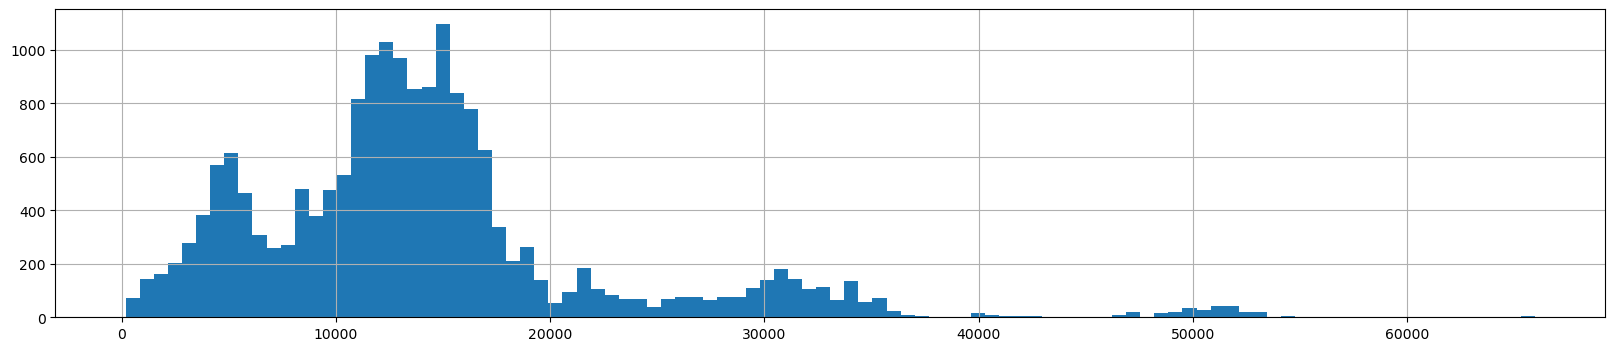

In [28]:
data['city_centers_nearest'].hist(figsize=(20, 4), bins=100);

Let's build a scatter plot to show the relationship between the distance to the city center and the property price.

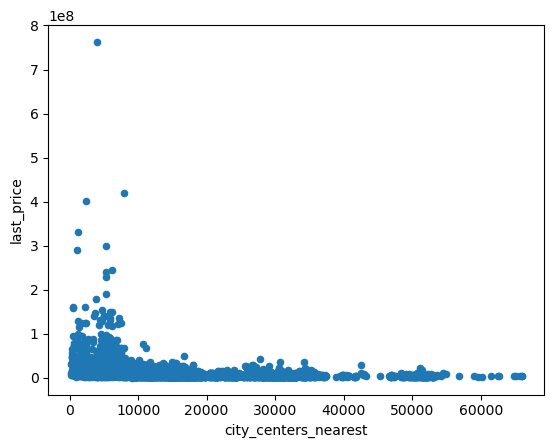

In [29]:
data.plot(x='city_centers_nearest', y='last_price', kind='scatter');

The chart clearly shows that apartments closer to the city center are more expensive than those farther away.  
This means that it's an important factor influencing the price, and filling in missing values with the median or mean could significantly distort the results.

From the initial data exploration, it is known that this column had 5,519 missing values (some have already been removed).  
Let's examine the distribution of missing values across localities before filling in the **'city_centers_nearest'** column.

In [30]:
# Looking for the number of missing values in the 'city_countries_nearest' column
data[data['city_centers_nearest'].isna()]['locality_name'].value_counts().sum()

5352

In [31]:
# Display the 10 localities with the highest number of missing values in the column
missing_city_center = data[data['city_centers_nearest'].isna()]['locality_name'].value_counts()
missing_city_center.head(10)

locality_name
Мурино             576
Кудрово            467
Всеволожск         390
Гатчина            278
Выборг             215
Новое Девяткино    143
Сертолово          137
Кириши             115
Бугры              112
Волхов             105
Name: count, dtype: int64

In [32]:
missing_city_center.head(10).sum()

2538

In [33]:
missing_city_center.count()

287

There are missing values in 287 localities.

Half of the missing values (2,538) are concentrated in the top 10 localities.

In [34]:
# Display the total number of ads
localities = ['Мурино', 'Кудрово', 'Всеволожск', 'Гатчина', 'Выборг', 
              'Новое Девяткино', 'Сертолово', 'Кириши', 'Бугры', 'Волхов']
for locality in localities:
    print(locality, data[data['locality_name'] == locality].shape[0])

Мурино 576
Кудрово 467
Всеволожск 390
Гатчина 278
Выборг 215
Новое Девяткино 143
Сертолово 137
Кириши 115
Бугры 112
Волхов 105


It turns out that in these localities, the distance to the city center is not filled in at all.  
This means we cannot draw any conclusions about the impact of this parameter on apartment prices in these areas.  
Therefore, we should leave the missing values as they are, because filling them with the median or mean could significantly distort the results and conclusions.

In [35]:
# See the total number of ads by city
data['locality_name'].value_counts().head(10)

locality_name
Санкт-Петербург    15601
Мурино               576
Кудрово              467
Шушары               438
Всеволожск           390
Пушкин               367
Колпино              338
Парголово            326
Гатчина              278
Выборг               215
Name: count, dtype: int64

The largest number of dataframe ads is in St. Petersburg

In [36]:
# count the number of passes in 'cityCenters_nearest' in St. Petersburg
data[(data['city_centers_nearest'].isna()) & (data['locality_name'] == 'Санкт-Петербург')].shape[0]

60

60 lines are missing, delete them.

In [37]:
# Delete lines where 'city_centers_nearest' is missing and 'locality_name' equals 'St. Petersburg'
data = data[~((data['city_centers_nearest'].isna()) & (data['locality_name'] == 'Санкт-Петербург'))]

In [38]:
# Check
data[(data['city_centers_nearest'].isna()) & (data['locality_name'] == 'Санкт-Петербург')].shape[0]

0

**Conclusion:**

**Missing Values Distribution:**  
Half of all missing values (2,538 out of 5,352) are concentrated in the top 10 localities (excluding Saint Petersburg) with the highest number of listings. This indicates systematic issues in data collection in these regions.

**Handling Missing Values for Saint Petersburg:**  
It was decided to remove 60 rows with missing values for Saint Petersburg, as they represent a small portion of the total listings (15,601), and the parameter in question may have a significant impact on apartment prices.

**Decision for Other Localities:**  
Missing values in other localities were left unchanged to avoid distorting the results.

##### Column 'airports_nearest'

We are analyzing the **`'airports_nearest'`** column (distance to the nearest airport). Let's plot a histogram:

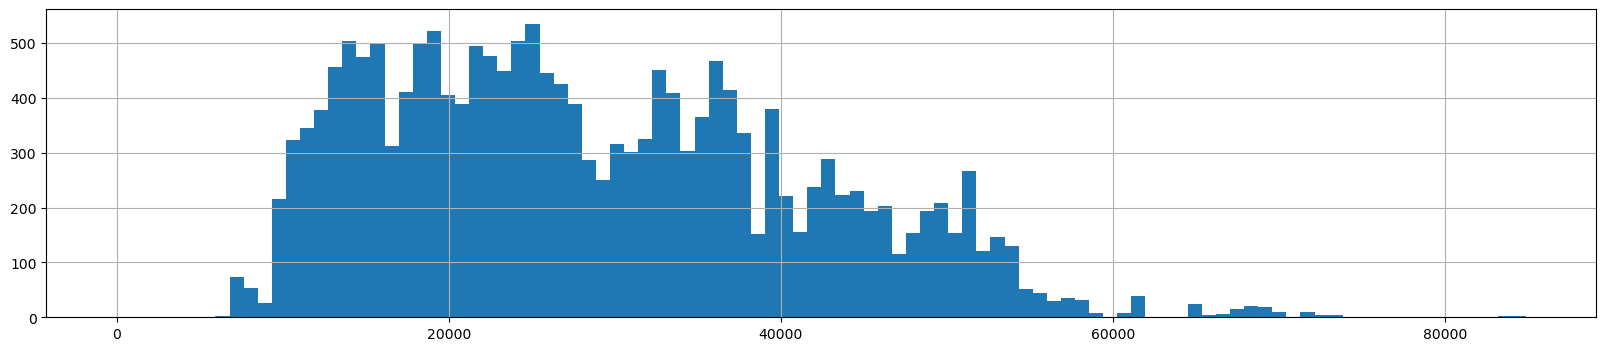

In [39]:
data['airports_nearest'].hist(figsize=(20, 4), bins=100);

Let's plot a scatter diagram to show the relationship between the distance to the airport and the property price.

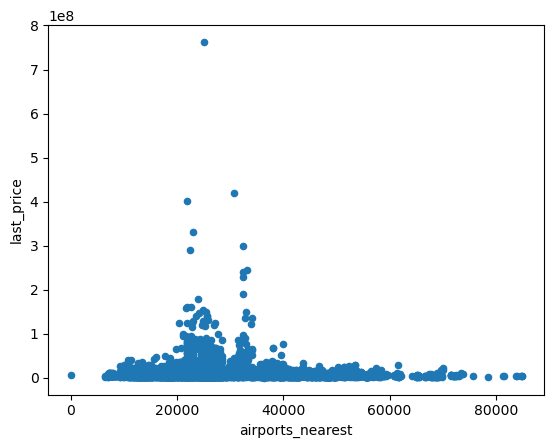

In [40]:
data.plot(x='airports_nearest', y='last_price', kind='scatter');

As the graph shows, there is no clear correlation between price and distance to the airport. The most expensive properties are located at a distance of 2 to 3.5 km.

In [41]:
# Looking for the number of missing values in the column
data[data['airports_nearest'].isna()]['locality_name'].value_counts().sum()

5315

In [42]:
# We output the 10 localities with the highest number of missing values in the column
data[data['airports_nearest'].isna()]['locality_name'].value_counts().head(10)

locality_name
Мурино             576
Кудрово            467
Всеволожск         390
Гатчина            278
Выборг             215
Новое Девяткино    143
Сертолово          137
Кириши             115
Бугры              112
Волхов             105
Name: count, dtype: int64

**Conclusion:**  
The missing values occur in the same listings as in the `'city_centers_nearest'` column. This confirms the suspicion of data collection issues in those localities. Since the distance to the airport does not appear to be a significant factor influencing property prices, we will leave it unchanged.

##### Column 'parks_nearest'

We are analyzing the **`'parks_nearest'`** column (distance to the nearest park). Let's plot a histogram:

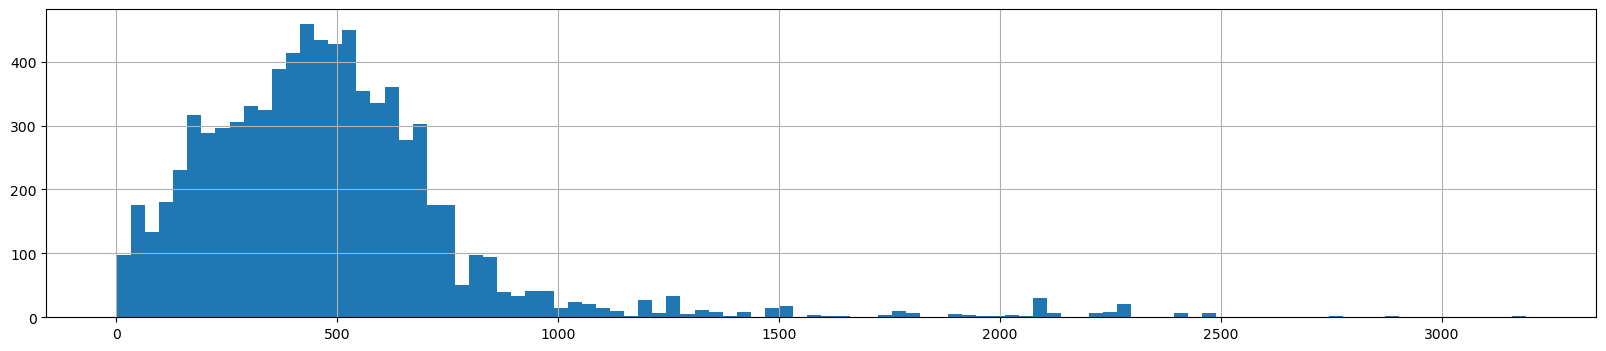

In [43]:
data['parks_nearest'].hist(figsize=(20, 4), bins=100);

Most real estate properties are located relatively close to parks (from 0 to 800 meters),  
with peak values around 300–600 meters.

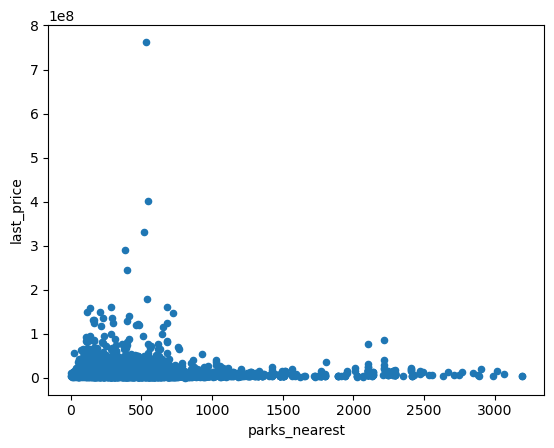

In [44]:
data.plot(x='parks_nearest', y='last_price', kind='scatter');

It can be said that proximity to a park has a certain influence on property prices  
(the most expensive apartments are located within approximately 700 meters from parks).

In [45]:
# Checking the number of missing values in the column
data[data['parks_nearest'].isna()]['locality_name'].value_counts().sum()

15290

In [46]:
# Displaying the 10 localities with the highest number of missing values in the column
data[data['parks_nearest'].isna()]['locality_name'].value_counts().head(10)

locality_name
Санкт-Петербург    8312
Мурино              576
Кудрово             467
Шушары              438
Всеволожск          390
Парголово           316
Гатчина             278
Выборг              215
Колпино             205
Пушкин              155
Name: count, dtype: int64

As expected, missing values are observed in Murino, Kudrovo, Vsevolozhsk, etc.  
However, missing values also appear in other cities such as Shushary, Pargolovo, Kolpino, Pushkin, and so on.  
The highest number of missing values (8,312) is in Saint Petersburg.

**Conclusion:**  
Based on the plots, we can say that proximity to a park has a certain impact on property prices.  
However, too much data is missing (over 65%), making it difficult to draw reliable conclusions.  
Filling the gaps with mean or median values could significantly distort the results, so it was decided to leave the missing values as they are, even in the future.  
Going forward, it's important to pay attention to the mapping of parks on the map, especially in Saint Petersburg.

##### Column 'ponds_nearest'

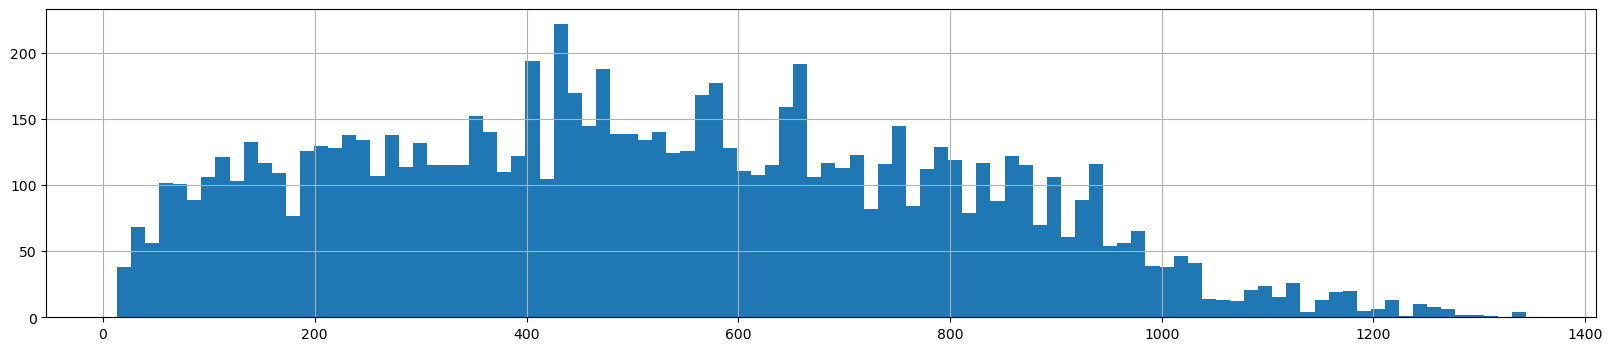

In [47]:
data['ponds_nearest'].hist(figsize=(20, 4), bins=100);

In [48]:
# Checking the number of missing values in the column
data[data['ponds_nearest'].isna()]['locality_name'].value_counts().sum()

14289

In [49]:
# Displaying the top 10 localities with the highest number of missing values in the column
data[data['ponds_nearest'].isna()]['locality_name'].value_counts().head(10)

locality_name
Санкт-Петербург    7632
Мурино              576
Кудрово             467
Всеволожск          390
Шушары              286
Гатчина             278
Парголово           270
Выборг              215
Пушкин              190
Красное Село        163
Name: count, dtype: int64

Expected missing values are observed in Murino, Kudrovo, Vsevolozhsk, and others, as well as in cities like Shushary, Pargolovo, Pushkin, etc.  
The highest number of missing values (7,632) is in Saint Petersburg.

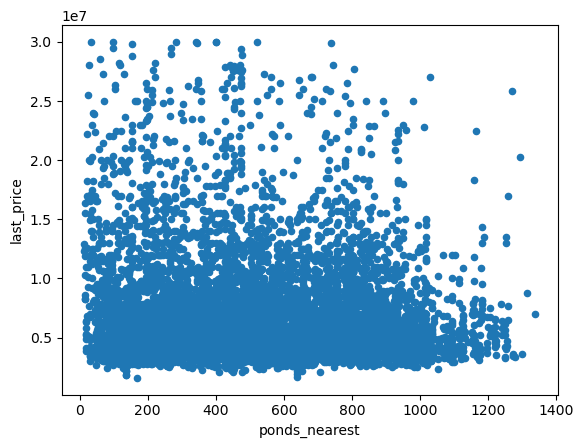

In [163]:
# Checking if there is a correlation between these two values (selecting rows where 'ponds_nearest' is not missing)
spb_data.plot(x='ponds_nearest', y='last_price', kind='scatter');

**Conclusion:**  
There is no significant correlation between price and distance to ponds (the scatter plot shows a uniform distribution of points along the distance axis).  
The most expensive apartments (over 10 million rubles) are located 600–800 meters from a pond, but this represents a fairly limited number of properties.  
In principle, the columns could be filled with the median value, but too much data is missing (over 60%), so such imputation could distort the results.  
Therefore, it was decided to leave the missing values as they are.  
This confirms major issues with automated data collection (parks and ponds may simply not be mapped in many areas — for example, in Saint Petersburg).

##### Column 'days_exposition'  
Let's explore the column showing the number of days the listing was active.  
I'm trying to understand the possible reasons for missing values.  
To do this, I'm displaying the rows with missing values.

In [51]:
data[data['days_exposition'].isna()]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around_3000,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,distance_to_center_km
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51,8,False,...,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,16.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,2.60,24.0,40,22,False,...,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN,12.0
44,13,5350000.0,40.00,2018-11-18T00:00:00,1,2.70,22.0,22,3,False,...,1.0,Санкт-Петербург,30471.0,11603.0,1.0,620.0,1.0,1152.0,NaN,12.0
45,17,5200000.0,50.60,2018-12-02T00:00:00,2,2.55,9.0,30,7,False,...,0.0,Санкт-Петербург,30011.0,12872.0,0.0,NaN,0.0,NaN,NaN,13.0
46,17,6600000.0,52.10,2019-01-31T00:00:00,2,2.60,24.0,29,9,False,...,2.0,Санкт-Петербург,15114.0,12702.0,0.0,NaN,0.0,NaN,NaN,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23684,20,21400000.0,145.00,2018-11-02T00:00:00,4,3.00,26.0,71,17,False,...,0.0,Санкт-Петербург,11827.0,11459.0,0.0,NaN,0.0,NaN,NaN,11.0
23685,15,2490000.0,31.00,2019-01-24T00:00:00,1,2.50,5.0,17,5,False,...,1.0,Ломоносов,48393.0,51818.0,0.0,NaN,0.0,NaN,NaN,52.0
23694,9,9700000.0,133.81,2017-03-21T00:00:00,3,3.70,5.0,73,3,False,...,0.0,Санкт-Петербург,24665.0,4232.0,1.0,796.0,3.0,381.0,NaN,4.0
23696,18,2500000.0,56.70,2018-02-11T00:00:00,2,2.64,3.0,29,1,False,...,0.0,Рождествено,NaN,NaN,0.0,NaN,0.0,NaN,NaN,NaN


There are listings in the table with missing values in the `days_exposition` column from 2017, 2018, and 2019.

**Possible reasons:**

1. The listings are still active.  
2. Listings were removed without recording the date (sellers may have deliberately not specified the duration).  
3. Technical errors during data collection or transmission.

For now, I’ve decided to leave the missing values as they are, since it's difficult to trace the impact of this variable.  
Sometimes, the same apartment is listed for sale multiple times. In other cases, a listing may be removed without an actual sale (and in general, this table doesn’t guarantee that a sale actually took place).

In short, missing values have been filled where possible.

In [52]:
data.isna().sum()

total_images                 0
last_price                   0
total_area                   0
first_day_exposition         0
rooms                        0
ceiling_height               0
floors_total                 0
living_area                  0
floor                        0
is_apartment                 0
studio                       0
open_plan                    0
kitchen_area                 0
balcony                      0
locality_name                0
airports_nearest          5315
city_centers_nearest      5292
parks_around_3000            0
parks_nearest            15290
ponds_around_3000            0
ponds_nearest            14289
days_exposition           3098
distance_to_center_km     5292
dtype: int64

#### Setting the correct data types

The columns that need a data type change:

**'floors_total'**, **'balcony'**, **'parks_around3000'**, **'ponds_around3000'**, and **'days_exposition'** should be converted to `int`, since these columns represent countable values (number of floors, balconies, parks, and days).  
Using `int` is more convenient for calculations and analysis, helps with memory optimization, and improves readability.

In [53]:
columns_to_convert = ['floors_total', 'balcony', 'parks_around_3000', 'ponds_around_3000', 'days_exposition']

for column in columns_to_convert:
    data[column] = data[column].fillna(0).astype(int)

**'first_day_exposition'**  
Let's check the date format.

Each column now has the correct data type.  
An explanation has been provided for which columns had their data types changed and why.

In [54]:
data['first_day_exposition'].dtypes

dtype('O')

The data type `dtype('O')` in pandas means that the values in the `first_day_exposition` column are of type "object", i.e., the dates are stored as strings.  
For easier handling of dates, they should be converted to datetime format using `pd.to_datetime()`.

In [55]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['first_day_exposition']

0       2019-03-07
1       2018-12-04
2       2015-08-20
3       2015-07-24
4       2018-06-19
           ...    
23694   2017-03-21
23695   2018-01-15
23696   2018-02-11
23697   2017-03-28
23698   2017-07-21
Name: first_day_exposition, Length: 23296, dtype: datetime64[ns]

In [56]:
# Checking data types
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23296 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   total_images           23296 non-null  int64         
 1   last_price             23296 non-null  float64       
 2   total_area             23296 non-null  float64       
 3   first_day_exposition   23296 non-null  datetime64[ns]
 4   rooms                  23296 non-null  int64         
 5   ceiling_height         23296 non-null  float64       
 6   floors_total           23296 non-null  int32         
 7   living_area            23296 non-null  int32         
 8   floor                  23296 non-null  int64         
 9   is_apartment           23296 non-null  bool          
 10  studio                 23296 non-null  bool          
 11  open_plan              23296 non-null  bool          
 12  kitchen_area           23296 non-null  int32         
 13  balcon

#### Processing of abnormal values



In [57]:
# check

# Statistics on the number of listings in the dataset, as well as the minimum and maximum values  
# for selected apartment sale parameters  
# raw data

(
    data[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  'kitchen_area',
          'floor', 'floors_total']]
    .apply (['count', 'min', 'max', 'median'])   
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
count,"23,296.00","23,296.00","23,296.00","23,296.00","23,296.00","23,296.00","23,296.00","23,296.00","23,296.00"
min,0.00,12.00,1.00,0.00,"12,190.00",2.00,1.00,1.00,1.00
max,19.00,900.00,100.00,"1,580.00","763,000,000.00",409.00,112.00,33.00,60.00
median,2.00,52.00,2.64,74.00,"4,650,000.00",30.00,9.00,4.00,9.00


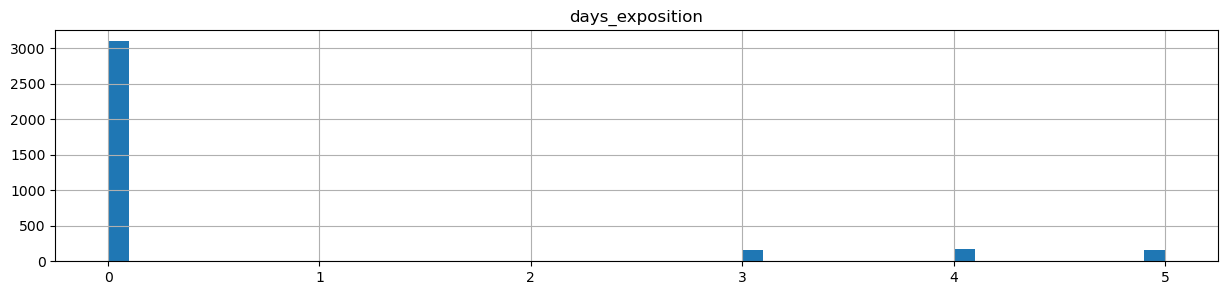

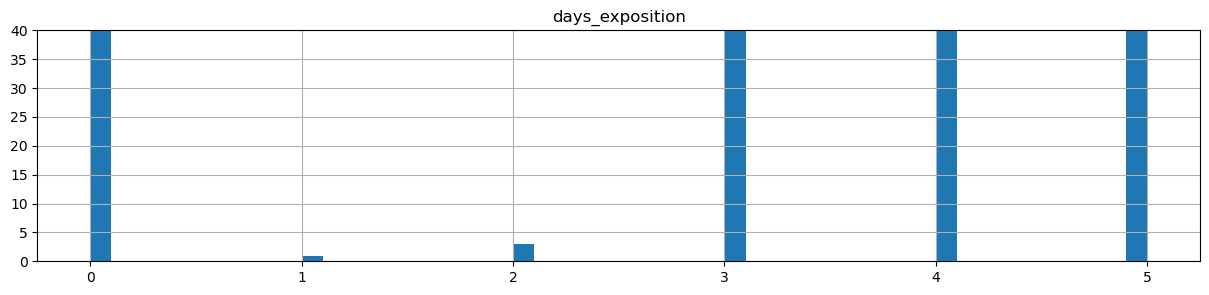

In [58]:
# check
data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5));

data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5))
plt.ylim(0, 40);

In [59]:
# check

# Values of real estate property parameters at different quantiles


(
    data[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  
          'kitchen_area', 'floor', 'floors_total']]
    .quantile([0.0012, 0.01, .5, .99, .9988])  # selecting a range of 0.9976 quantiles
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
0.001200,0.00,20.00,2.40,0.00,"560,000.00",9.00,3.00,1.00,2.00
0.010000,1.00,25.33,2.50,0.00,"1,000,000.00",13.00,4.00,1.00,2.00
0.500000,2.00,52.00,2.64,74.00,"4,650,000.00",30.00,9.00,4.00,9.00
0.990000,5.00,197.23,3.69,"1,043.10","35,290,500.00",122.00,35.00,23.00,26.00
0.998800,8.00,380.00,8.00,"1,362.05","124,503,920.00",230.41,63.00,26.00,35.00


##### Column 'rooms'

In [60]:
# Displaying all unique values in the column
data['rooms'].sort_values().unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 14, 15, 16, 19],
      dtype=int64)

In [61]:
data.rooms.value_counts()

rooms
1     7905
2     7805
3     5716
4     1165
5      321
0      194
6      102
7       57
8       12
9        8
10       3
11       2
14       2
15       1
19       1
16       1
12       1
Name: count, dtype: int64

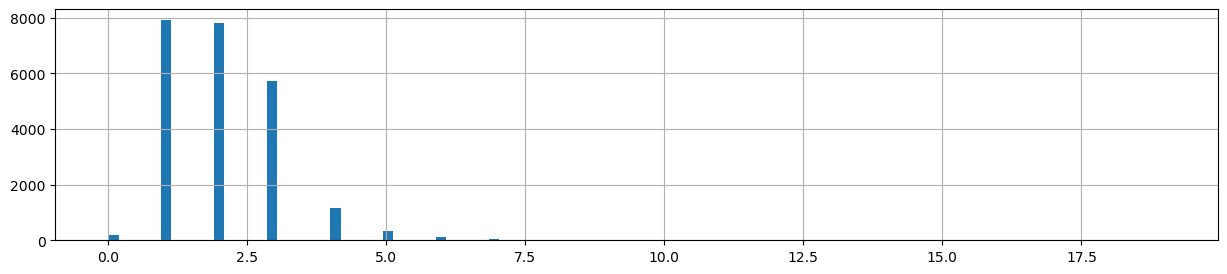

In [62]:
# Plotting a histogram
data.rooms.hist(bins = 100, figsize = (15,3));

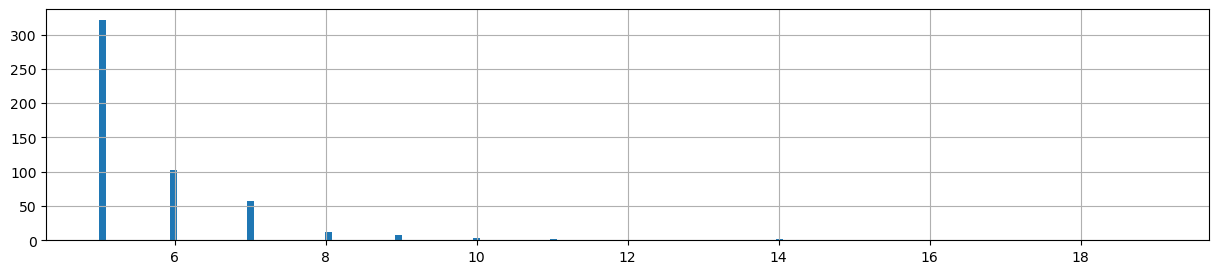

In [63]:
# Approximating part of the graph from 5 to 19 rooms
data.rooms.hist(bins = 150, figsize = (15,3), range = (5, 19));

Apartments with more than 7 rooms are unique properties that require separate analysis in our study.  
Therefore, it makes sense to remove them from the dataset.

In [64]:
# Counting the number of rows where the number of rooms is greater than 7.
data[data['rooms'] > 7].shape[0]

31

In [65]:
# Removing
data = data[data['rooms'] <= 7].reset_index(drop=True)

# Checking the number of rows after removal
data.shape[0]

23265

##### Column 'total_area'

In [66]:
data['total_area'].describe()

count    23265.000000
mean        59.972444
std         34.033470
min         12.000000
25%         40.000000
50%         52.000000
75%         69.500000
max        631.200000
Name: total_area, dtype: float64

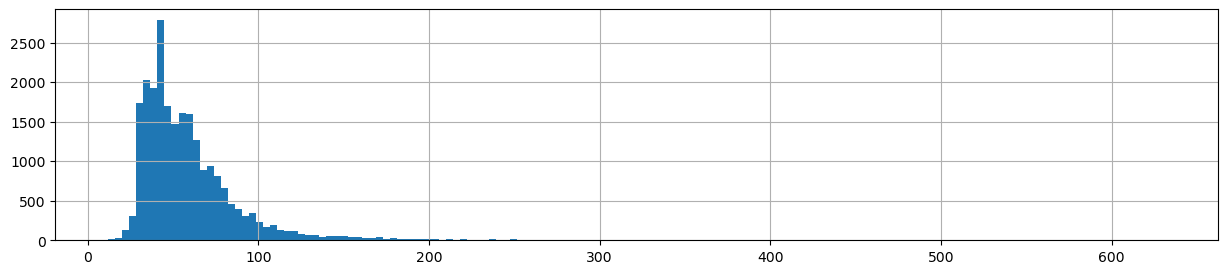

In [67]:
# Plotting a histogram
data.total_area.hist(bins = 150, figsize = (15,3));

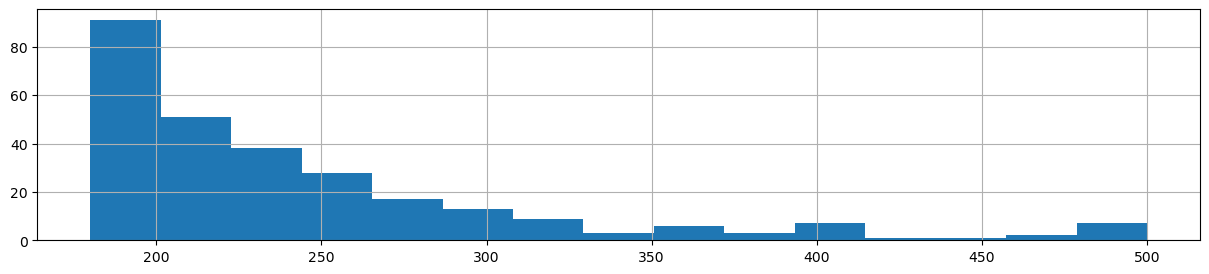

In [68]:
# Limiting the range to values between 180 and 500 square meters
data.total_area.hist(bins = 15, figsize = (15,3), range = (180,500));

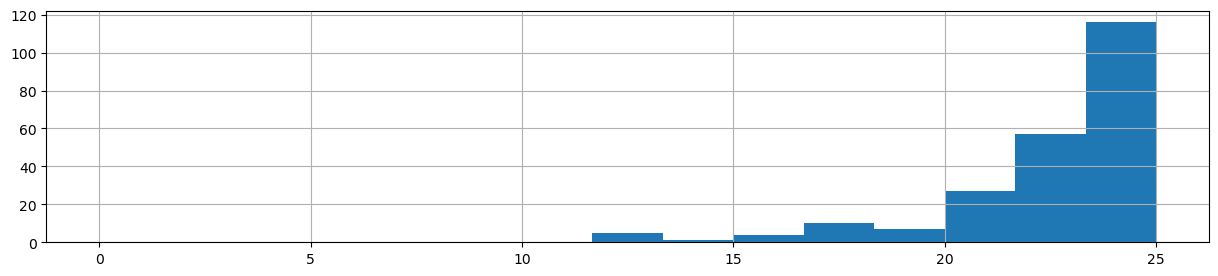

In [69]:
# Limiting the range to values from 0 to 25 square meters
data.total_area.hist(bins = 15, figsize = (15,3), range = (0,25));

In [70]:
# Counting the number of rows with area less than 20 and more than 250 meters
data[(data['total_area'] < 20) | (data['total_area'] > 250)]['total_area'].count()

119

In [71]:
# Removing rows where the total area is less than 20 or greater than 250 square meters
data = data[~((data['total_area'] < 20) | (data['total_area'] > 250))].reset_index(drop=True)

# Checking the number of rows after removal
data.shape[0]

23146

##### Column 'ceiling_height'

In [72]:
data['ceiling_height'].describe()

count    23146.000000
mean         2.758135
std          1.178652
min          1.000000
25%          2.600000
50%          2.640000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

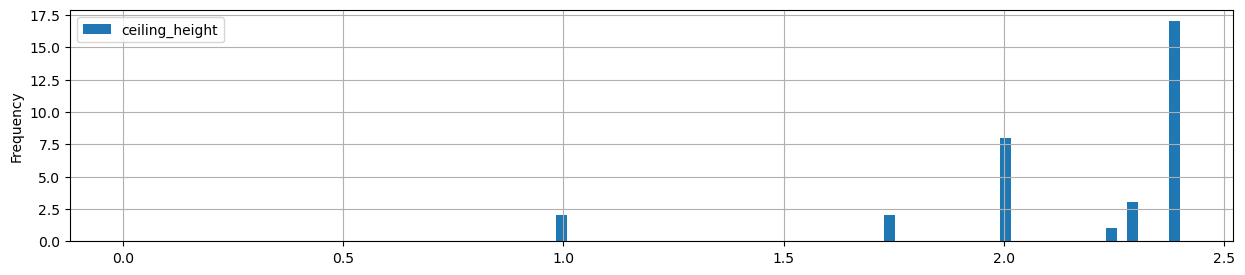

In [73]:
# Plotting a histogram of the distribution of anomalous values (ceiling height less than 2.3 meters)
data.plot(y = 'ceiling_height', bins = 100, grid = True, kind = 'hist', figsize = (15,3), range=(0, 2.4));

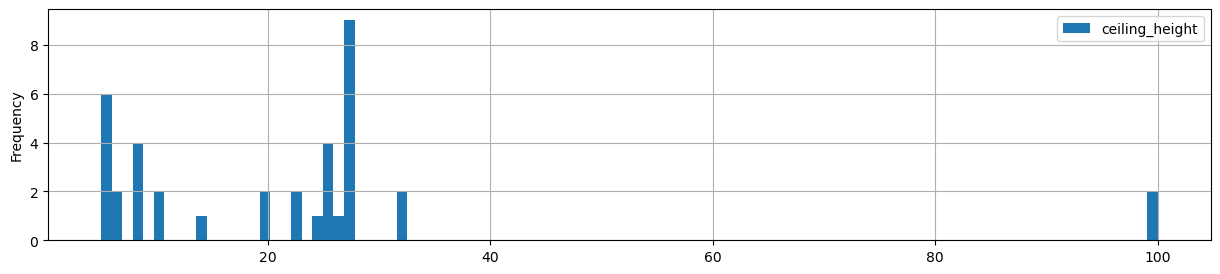

In [74]:
# Plotting a histogram of the distribution of anomalous values (ceiling height more than 5 meters)
data.plot(y = 'ceiling_height', bins = 100, grid = True, kind = 'hist', figsize = (15,3), range=(5, 100));

In [75]:
# Filter rows with non-standard ceiling height values and count their number.
data[(data['ceiling_height'] > 5) | (data['ceiling_height'] < 2.4)]['ceiling_height'].value_counts().to_frame()

,count
ceiling_height,
2.00,8
27.00,7
25.00,4
8.00,3
2.30,3
6.00,2
100.00,2
1.00,2
32.00,2


Values between 24 and 50 meters are most likely typos and can be corrected.

In [76]:
# Condition: ceiling height is between 24 and 50 meters
condition = (data['ceiling_height'] >= 24) & (data['ceiling_height'] <= 50)

# Correcting ceiling height by dividing by 10 for likely erroneous values
data.loc[condition, 'ceiling_height'] = data.loc[condition, 'ceiling_height'] / 10


In [77]:
data[(data['ceiling_height'] < 2.4) | (data['ceiling_height'] > 5)]['ceiling_height'].count()

37

The number of rows with such values is 37. They can be removed.

In [78]:
# Exclude rows where ceiling height is below 2 meters or above 5 meters.
data = data[~((data['ceiling_height'] < 2.3) | (data['ceiling_height'] > 5))].reset_index(drop=True)

count    23112.000000
mean         2.726139
std          0.244758
min          2.300000
25%          2.600000
50%          2.640000
75%          2.800000
max          4.900000
Name: ceiling_height, dtype: float64

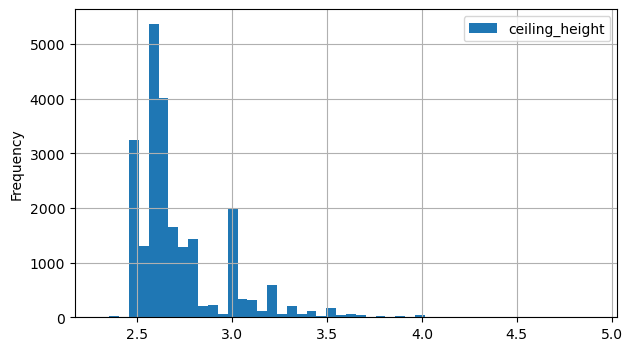

In [79]:
# Plotting the histogrm
data.plot(y = 'ceiling_height', bins = 50, grid = True, kind = 'hist', figsize = (7,4))

# Checking the key values in the column after removing the rows.
data['ceiling_height'].describe()

In [80]:
# Check the number of rows after removing
data.shape[0]

23112

##### Column 'days_exposition'

In [81]:
data['days_exposition'].describe()

count    23112.000000
mean       156.068233
std        212.779810
min          0.000000
25%         23.000000
50%         73.000000
75%        198.000000
max       1580.000000
Name: days_exposition, dtype: float64

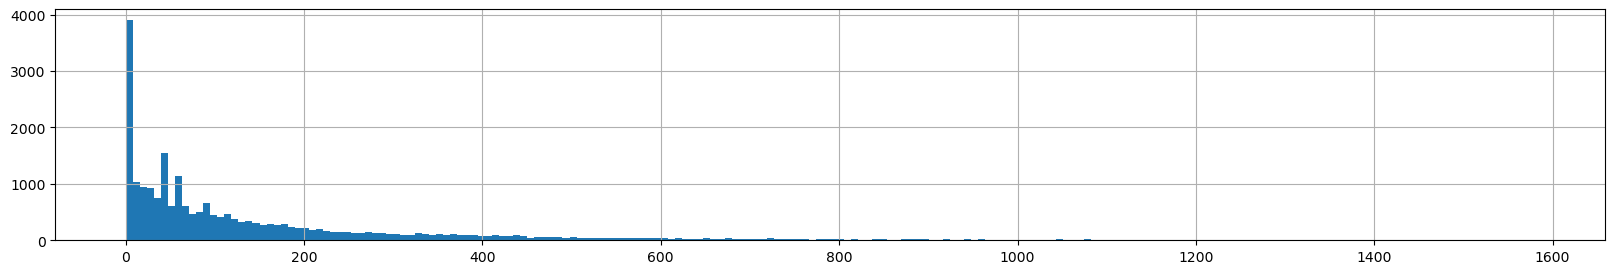

In [82]:
# Plotting the histogram
data.days_exposition.hist(bins = 200, figsize = (20,3));

The histogram shows a peak around 0 and a long tail extending up to 1,600 days.

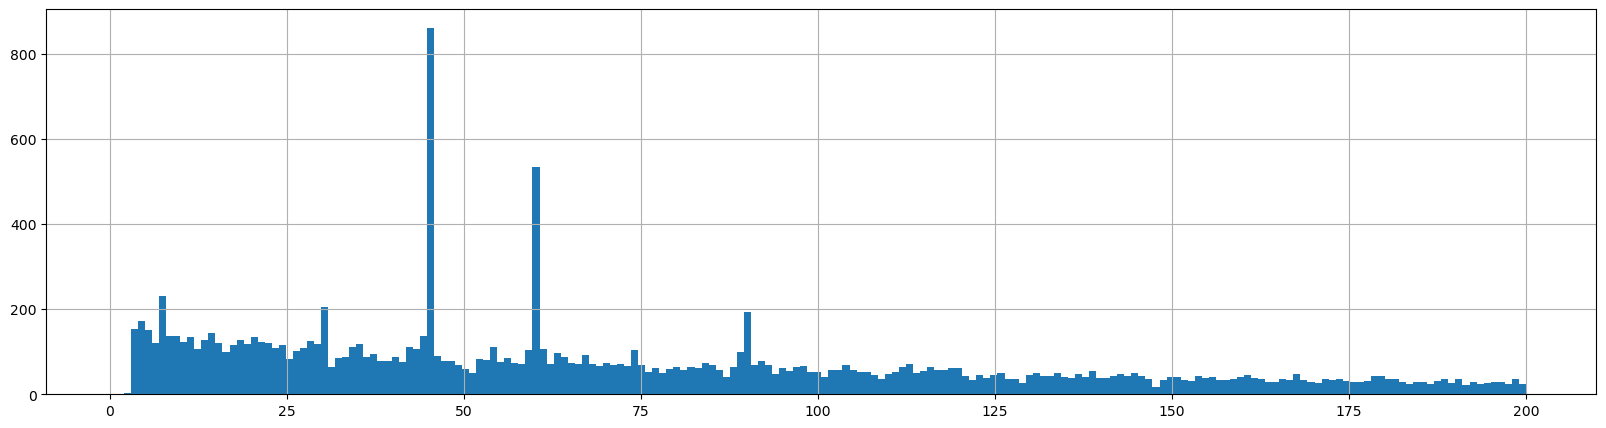

In [83]:
# Plotting a histogram from 1 to 200 days.
data.days_exposition.hist(bins = 200, figsize = (20,5), range=(1, 200));

In [84]:
# Identify the outlier values
data['days_exposition'].value_counts().head(10)

days_exposition
0     3069
45     861
60     534
7      231
30     205
90     193
4      171
3      153
5      151
14     144
Name: count, dtype: int64

The average value is 156 days, and the median is 74 days.

Identified outlier values: 0, 7, 30, 45, 60, and 90 days.  
Possible reasons for their appearance:

1. Listings that were removed or unpublished on the same day they were posted (for various reasons) may automatically get a `days_exposition` value of 0.  
2. The publication durations on Yandex correspond to these time periods (this information was verified on the Yandex Real Estate website).

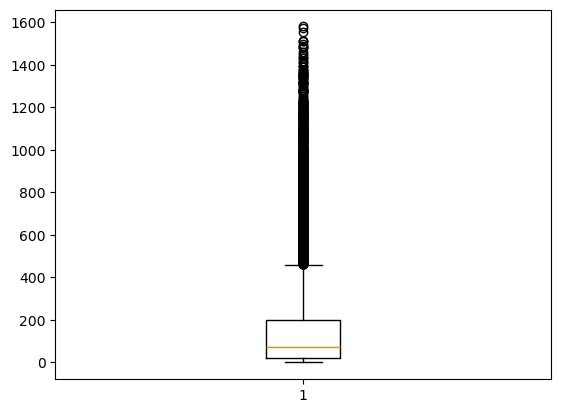

In [85]:
plt.boxplot(data['days_exposition']);

The boxplot shows that the "normal" data is in the range of 1 to 250 days, while outliers appear at 500 days and above.

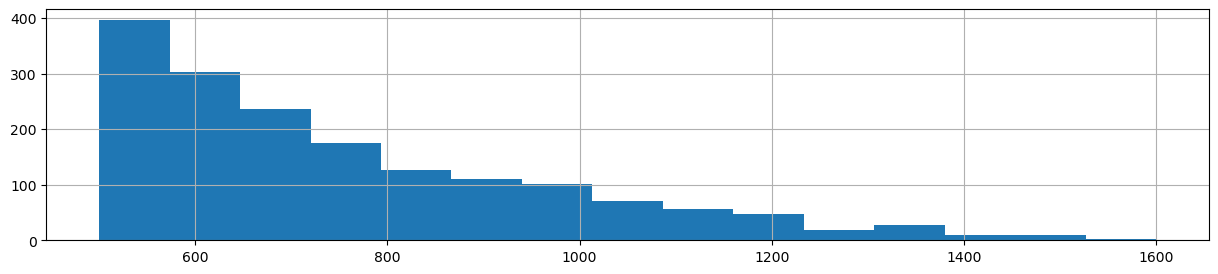

In [86]:
# Limiting the range to values between 500 and 1600 days
data.days_exposition.hist(bins = 15, figsize = (15,3), range = (500,1600));

In [87]:
data[data['days_exposition'] > 800].shape[0]

567

To avoid losing a large number of rows, we'll remove only the listings that were on the market for more than 800 days.

In [88]:
# Removing rows where days_exposition > 800
data = data[data['days_exposition'] <= 800].reset_index(drop=True)

# Checking the number of rows after removal
data.shape[0]


22545

##### Column 'last_price'


In [89]:
data['last_price'].describe().apply(lambda x: format(x, ',.2f'))

count         22,545.00
mean       6,126,599.61
std        6,915,034.02
min           12,190.00
25%        3,400,000.00
50%        4,600,000.00
75%        6,700,000.00
max      330,000,000.00
Name: last_price, dtype: object

There is a large gap between the median and mean prices, and a significant difference between the 75th percentile and the maximum price, which indicates the presence of outliers in the form of extremely expensive apartments.  
Let's calculate the number of such outliers and, if necessary, exclude them from the analysis.

In [90]:
data[data['last_price'] > 30000000].shape[0]

209

In [91]:
data = data[data['last_price'] <= 30000000].reset_index(drop=True)

In [92]:
# Looking for values less than 100,000.
data[data['last_price'] < 100000.0].shape[0]

1

In [93]:
# Removing rows with outlier values
data = data[~((data['last_price'] < 300000.0) | (data['last_price'] > 30000000))].reset_index(drop=True)

# Checking the size of the DataFrame after row removal
data.shape[0]

22335

In [94]:
data['last_price'].describe().apply(lambda x: format(x, ',.2f'))

count        22,335.00
mean      5,681,425.36
std       3,920,372.40
min         430,000.00
25%       3,400,000.00
50%       4,600,000.00
75%       6,600,000.00
max      30,000,000.00
Name: last_price, dtype: object

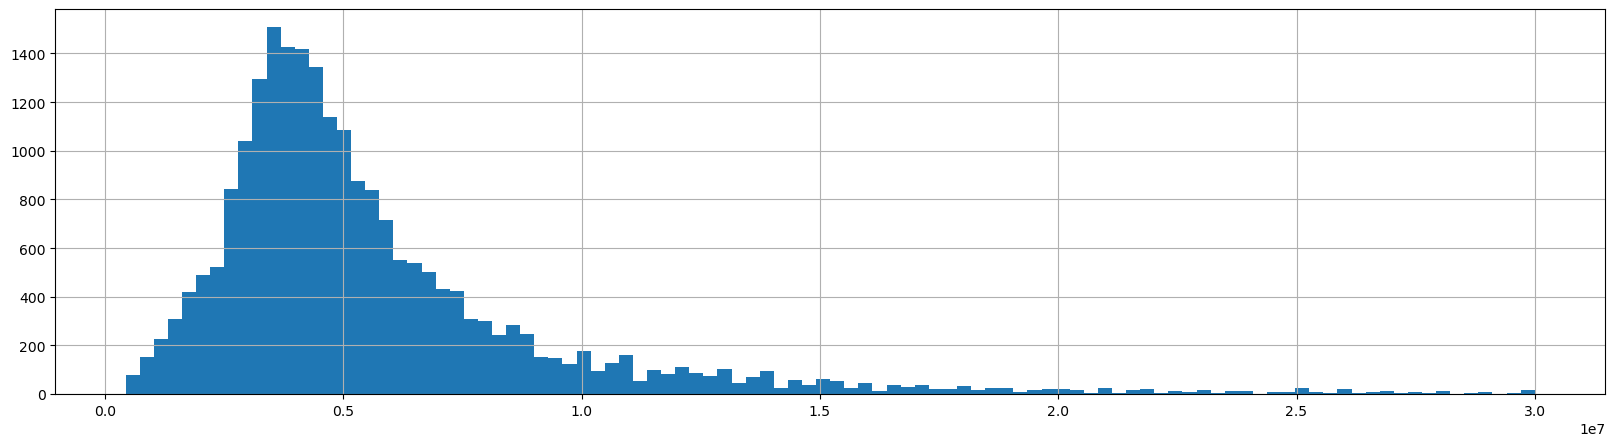

In [95]:
# Plotting a histogram
data.last_price.hist(bins = 100, figsize = (20,5));

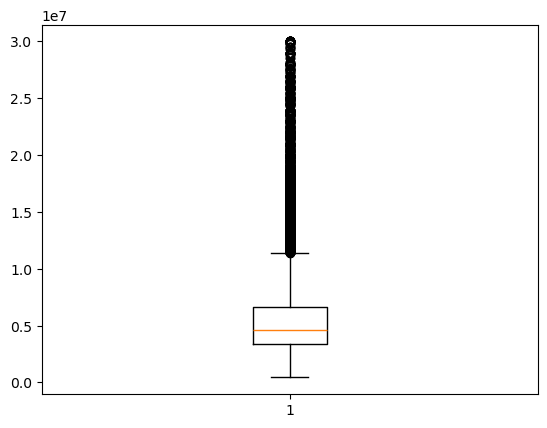

In [96]:
plt.boxplot(data['last_price']);

##### Сolumn 'living_area'

In [97]:
data['living_area'].describe()

count    22335.000000
mean        32.762973
std         17.297787
min          2.000000
25%         18.000000
50%         30.000000
75%         41.000000
max        180.000000
Name: living_area, dtype: float64

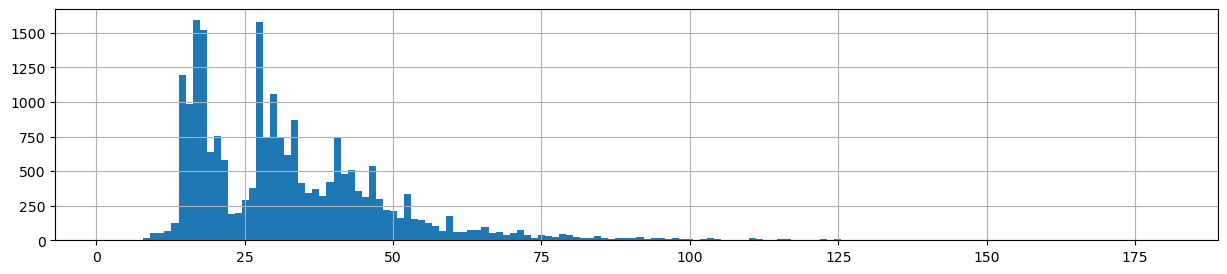

In [98]:
# Plotting a histogram
data.living_area.hist(bins = 150, figsize = (15,3));

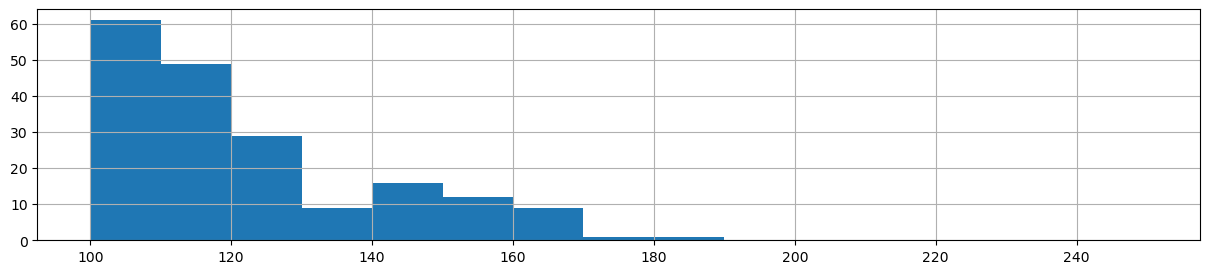

In [99]:
# Limit the range to values starting from 100 square meters
data.living_area.hist(bins = 15, figsize = (15,3), range = (100,250));

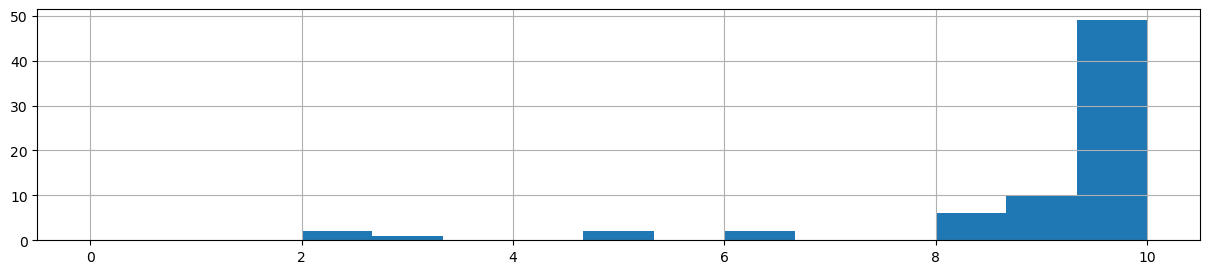

In [100]:
# Limit the range to values from 0 to 5 square meters
data.living_area.hist(bins = 15, figsize = (15,3), range = (0, 10));

In [101]:
# Count the number of rows with an area less than 8 or greater than 140 square meters
data[(data['living_area'] < 8) | (data['living_area'] > 140)]['living_area'].count()

42

In [102]:
# Remove rows with living area less than 8 or greater than 140 square meters
data = data[~((data['living_area'] < 8) | (data['living_area'] > 140))].reset_index(drop=True)

# Check the number of rows after removal
data.shape[0]


22293

##### Column 'kitchen_area'

In [103]:
data['kitchen_area'].describe()

count    22293.000000
mean         9.865653
std          4.996143
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         70.000000
Name: kitchen_area, dtype: float64

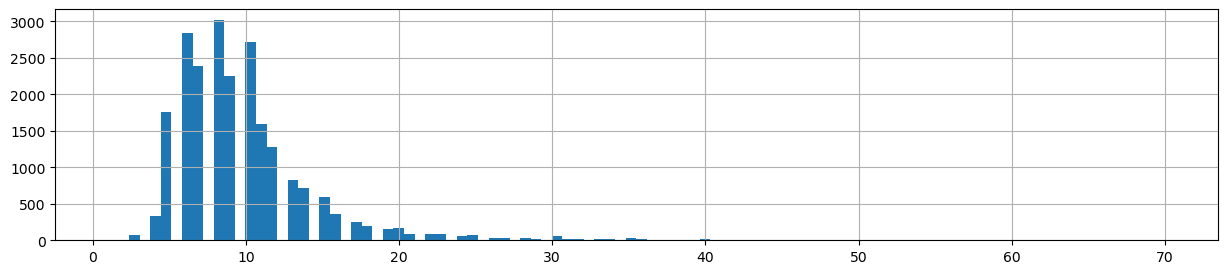

In [104]:
# Plotting a histogram
data.kitchen_area.hist(bins = 100, figsize = (15,3));

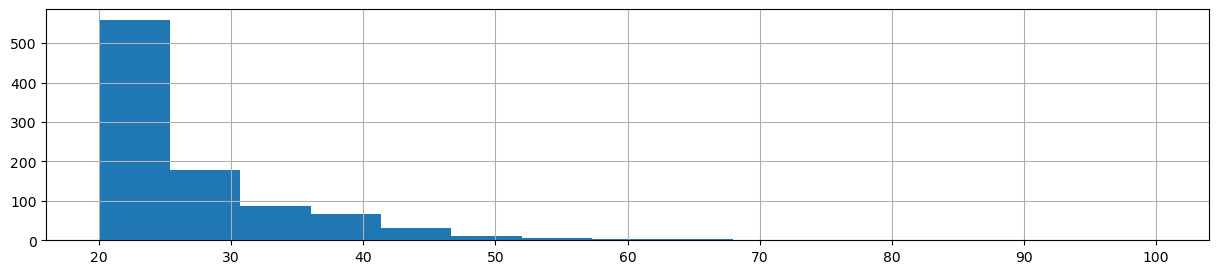

In [105]:
# Limit the range to values from 20 to 100 square meters
data.kitchen_area.hist(bins = 15, figsize = (15,3), range = (20, 100));

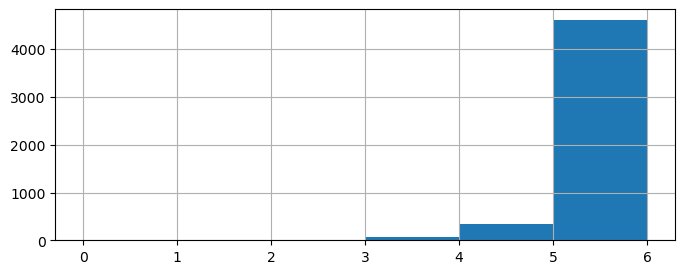

In [106]:
# Limit the range to values from 0 to 6 square meters.
data.kitchen_area.hist(bins = 6, figsize = (8,3), range = (0,6));

In [107]:
# Counting the number of rows with area less than 4 and more than 40 meters
data[(data['kitchen_area'] < 4) | (data['kitchen_area'] > 40)]['kitchen_area'].count()

141

In [108]:
# Removing lines with an area of less than 4 and more than 40 meters
data = data[~((data['kitchen_area'] < 4) | (data['kitchen_area'] > 40))].reset_index(drop=True)

# Check the number of rows after removal
data.shape[0]

22152

##### Column 'floor'

In [109]:
data['floor'].describe()

count    22152.000000
mean         5.906058
std          4.888174
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         33.000000
Name: floor, dtype: float64

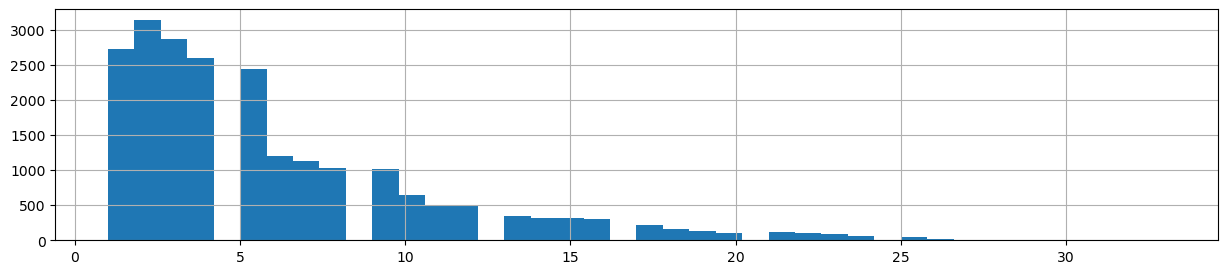

In [110]:
# Plotting a histogram
data.floor.hist(bins = 40, figsize = (15,3));

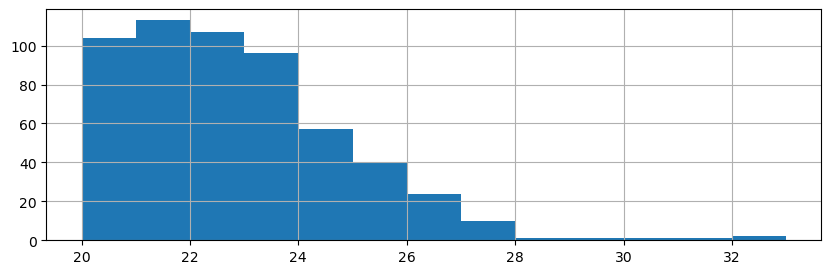

In [111]:
# Plotting a histogram for floors ranging from 20 to 33
data.floor.hist(bins = 13, figsize = (10,3), range=(20, 33));

In [112]:
# Counting the number of rows with floors above 27th floor
data[(data['floor'] > 27)]['floor'].count()

6

In [113]:
# Removing 
data = data[(data['floor'] <= 27)].reset_index(drop=True)

# Checking
data.shape[0]

22146

##### Column 'floors_total'

In [114]:
# check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22146 entries, 0 to 22145
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   total_images           22146 non-null  int64         
 1   last_price             22146 non-null  float64       
 2   total_area             22146 non-null  float64       
 3   first_day_exposition   22146 non-null  datetime64[ns]
 4   rooms                  22146 non-null  int64         
 5   ceiling_height         22146 non-null  float64       
 6   floors_total           22146 non-null  int32         
 7   living_area            22146 non-null  int32         
 8   floor                  22146 non-null  int64         
 9   is_apartment           22146 non-null  bool          
 10  studio                 22146 non-null  bool          
 11  open_plan              22146 non-null  bool          
 12  kitchen_area           22146 non-null  int32         
 13  b

In [115]:
data['floors_total'].describe()

count    22146.000000
mean        10.757609
std          6.608433
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

In [116]:
data['rooms'].describe()

count    22146.000000
mean         2.022216
std          0.981267
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

In [117]:
data['floors_total'] = data['floors_total'].astype(int)

In [118]:
data['floors_total'].dtype

dtype('int32')

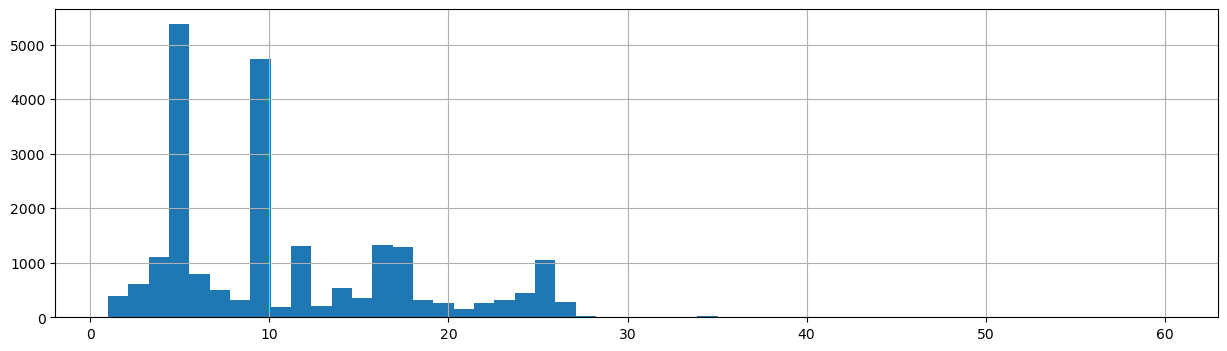

In [119]:
# Plotting a histogram
data.floors_total.hist(bins = 52, figsize = (15,4));

In [120]:
# Identifying outlier values
data['floors_total'].value_counts().head(10)

floors_total
5     5382
9     3621
16    1326
12    1304
10    1116
4     1099
25    1044
17     807
6      799
3      611
Name: count, dtype: int64

Peaks at levels 5 and 9 indicate that the most common types of buildings have 5 and 9 floors.  
Buildings with 16, 12, 10, and 25 floors are also frequently encountered.

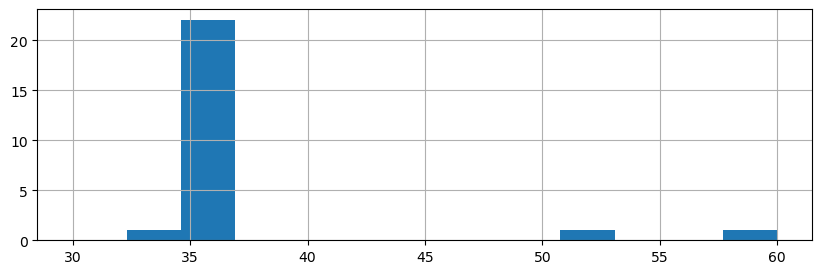

In [121]:
# Plotting a histogram for floors ranging from 30 to 60
data.floors_total.hist(bins = 13, figsize = (10,3), range=(30, 60));

In [122]:
# Counting the number of rows with a floor number greater than 40.
data[(data['floors_total'] > 40)]['floors_total'].count()

2

In [123]:
# Removing
data = data[(data['floors_total'] < 40)].reset_index(drop=True)

# Check
data.shape[0]

22144

In [124]:
# check

try:
    df_check = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
# if reading the file from the local folder fails, load the data from the web
except:
    df_check = pd.read_csv('real_estate_data.csv', sep='\t')

In [125]:
# check
df_check.rooms.value_counts().to_frame()

,count
rooms,
1,8047
2,7940
3,5814
4,1180
5,326
0,197
6,105
7,59
8,12


**Conclusion:** From the subset of "normal" apartments, we removed rare values that require separate analysis, as well as anomalous values that are most likely user input errors.

- `'rooms'` – 31 rows with more than 8 rooms were removed  
- `'total_area'` – 119 rows with area less than 20 or greater than 250 square meters were removed  
- `'ceiling_height'` – values between 20 and 33 meters were found (likely typos). These values were corrected. Additionally, 38 values with ceiling heights below 2.3 meters and above 5 meters were found and removed  
- `'days_exposition'` – outliers identified: 0 (listings removed the same day they were posted), 7, 30, 45, 60, 90 (standard listing durations). To avoid excessive loss of data, only listings with exposure longer than 800 days were removed (573 rows)  
- `'last_price'` – 1 value with a price of 12,190 RUB and 271 values over 30 million RUB (max = 763 million) were identified and removed  
- `'living_area'` – 60 rows with area less than 8 or greater than 140 square meters were identified and removed  
- `'kitchen_area'` – 147 rows with area less than 4 or greater than 40 square meters were identified and removed  
- `'floor'` – 6 rows with floor numbers greater than 27 were removed  
- `'floors_total'` – 2 rows with total floor count over 40 were removed  

**Record loss during preprocessing:**  
The initial dataset contained 23,699 rows. After preprocessing and removing anomalies, 22,144 rows remain, which accounts for approximately **6.5%** of the entire dataset.

### Adding new columns to the table

In [126]:
# price per square meter
data['price_per_sqm'] = (data['last_price'] / data['total_area']).round(2)

# day of the week when the listing was published
data['day_of_week'] = data['first_day_exposition'].dt.weekday

# month of publication
data['month_of_publication'] = data['first_day_exposition'].dt.month

# year of publication
data['year_of_publication'] = data['first_day_exposition'].dt.year

# distance to city center in kilometers
data['distance_to_center_km'] = (data['city_centers_nearest'] / 1000).round()


In [127]:
def floor_type(row):
    if row['floor'] <= 0 or row['floors_total'] <= 0:
        return 'некорректные данные'
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
        return 'последний'
    else:
        return 'другой'

data['floor_type'] = data.apply(floor_type, axis=1) # floor type

### Exploratory data analysis

#### Study parameters: area, price, number of rooms, ceiling height

In [128]:
quantitative_columns = ['total_area', 'living_area', 'kitchen_area', 'last_price', 
                        'rooms', 'ceiling_height', 'floors_total', 
                        'city_centers_nearest', 'parks_nearest']

data[quantitative_columns].describe()

,total_area,living_area,kitchen_area,last_price,rooms,ceiling_height,floors_total,city_centers_nearest,parks_nearest
count,22144.000000,22144.000000,22144.000000,2.214400e+04,22144.000000,22144.000000,22144.000000,17015.000000,7431.000000
mean,57.303178,32.574151,9.783102,5.634630e+06,2.022263,2.724045,10.753522,14440.072994,491.652671
std,25.130150,16.545537,4.559111,3.818847e+06,0.981287,0.242252,6.594618,8551.340353,337.128957
min,20.000000,8.000000,4.000000,4.300000e+05,0.000000,2.300000,1.000000,208.000000,1.000000
25%,40.000000,19.000000,7.000000,3.400000e+06,1.000000,2.600000,5.000000,9766.000000,289.000000
50%,51.000000,30.000000,9.000000,4.600000e+06,2.000000,2.640000,9.000000,13252.000000,456.000000
75%,67.800000,41.000000,11.000000,6.550000e+06,3.000000,2.800000,16.000000,16408.000000,613.000000
max,250.000000,140.000000,40.000000,3.000000e+07,7.000000,4.900000,36.000000,65952.000000,3190.000000


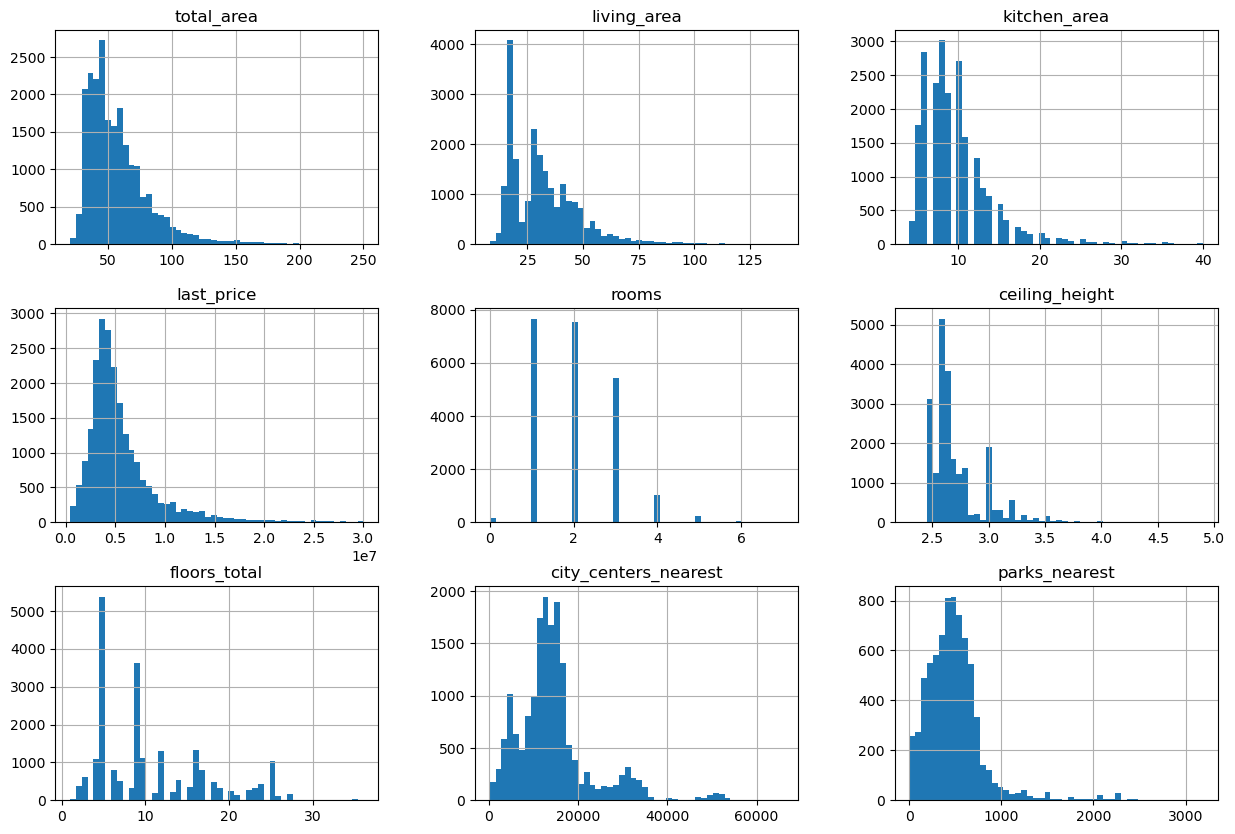

In [129]:
# Displaying histograms for the updated table.
data[quantitative_columns].hist(bins = 50, figsize=(15, 10));

Based on the processed data presented, the following observations can be made regarding the real estate market:

**Total Area:**  
The average total area of apartments is around 57 sq.m, with a median of 51 sq.m. The standard deviation is quite high (about 25.1 sq.m), indicating a wide range of apartment sizes — from compact units (minimum 20 sq.m) to very spacious ones (maximum 250 sq.m).

**Living Area:**  
The average living area is approximately 32.6 sq.m, with a median of 30 sq.m. Values range from 8 sq.m to 140 sq.m.

**Kitchen Area:**  
The average kitchen area is around 9.8 sq.m (median of 9 sq.m), with a maximum of 40 sq.m, which may indicate the presence of apartments with large or combined kitchen-living spaces.

**Property Price:**  
The average apartment price is around 6.54 million rubles, with a median of 4.65 million rubles. However, the high standard deviation and wide price range (from 430 thousand to 763 million rubles) point to significant variability in real estate prices. This may reflect differences in size, location, quality, and uniqueness of the properties.

**Number of Rooms:**  
On average, apartments have about 2 rooms, though options range from studios (0 rooms) to large 7-room apartments.

**Ceiling Height:**  
The average ceiling height is around 2.7 meters (median 2.64 m), which is standard for both modern and older buildings. The maximum height of 4.9 m may occur in apartments with lofted ceilings or in historic buildings.

**Building Floors:**  
The average number of floors in buildings is around 11, with a median of 9, and a maximum of 36 floors.

**Distance to City Center:**  
The average distance to the city center is about 14.4 km, with a median just under 13.3 km. There is a wide range—from very central locations (208 meters) to quite remote areas (up to 65.9 km).

**Distance to the Nearest Park:**  
The average distance to the nearest park is about 491 meters, with a median of 456 meters. However, many properties are located far from green spaces (with a maximum distance of 3,190 meters and a high degree of variability).

#### Exploring Floor Types

In [130]:
data['floor_type'] = data['floor_type'].replace({
    'первый': 'first',
    'последний': 'top',
    'другой': 'other'
})


data['floor_type'].value_counts()

floor_type
other    16326
top       3087
first     2731
Name: count, dtype: int64

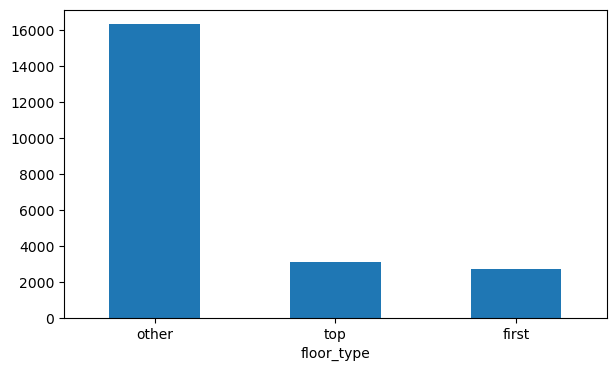

In [131]:
data['floor_type'].value_counts().plot(kind='bar', figsize=(7, 4), rot=0);

The "floor type" of an apartment can influence its price and desirability for buyers due to differences in noise levels, privacy, views, and other factors.

1. **First floor**: easy access, less privacy, possible street noise, and potential safety concerns.  
2. **Top floor**: no noise from above, often better views, but possible issues with the roof, heating problems, and limited accessibility (especially if the building has no elevator).  
3. **Other floors**: offer a balance between privacy and accessibility, less noise, but more limited views and lighting compared to the top floor.

#### Exploring Apartment Sale Duration

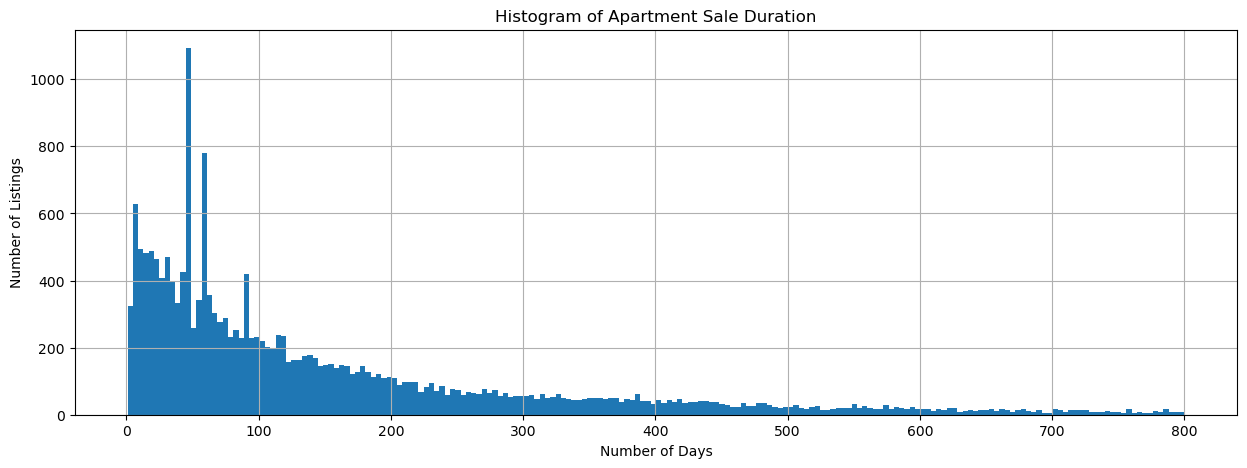

In [132]:
# Plotting a histogram for days_exposition
data['days_exposition'].hist(bins=200, figsize=(15, 5), range=(1, 800))
plt.title('Histogram of Apartment Sale Duration')
plt.xlabel('Number of Days')
plt.ylabel('Number of Listings')
plt.show()


In [133]:
# Get description of filtered data (exclude 0)
data[data['days_exposition'] != 0]['days_exposition'].describe()

count    19173.000000
mean       154.765660
std        164.161539
min          1.000000
25%         44.000000
50%         90.000000
75%        210.000000
max        800.000000
Name: days_exposition, dtype: float64

In [134]:
# Filter the DataFrame by excluding rows where 'days_exposition' is 0, 7, 30, 45, 60, or 90
filtered_data = data[~data['days_exposition'].isin([0, 7, 30, 45, 60, 90])]

# Get descriptive statistics for the filtered data
filtered_data['days_exposition'].describe()


count    17176.000000
mean       167.269329
std        168.914100
min          1.000000
25%         43.000000
50%        107.000000
75%        232.000000
max        800.000000
Name: days_exposition, dtype: float64

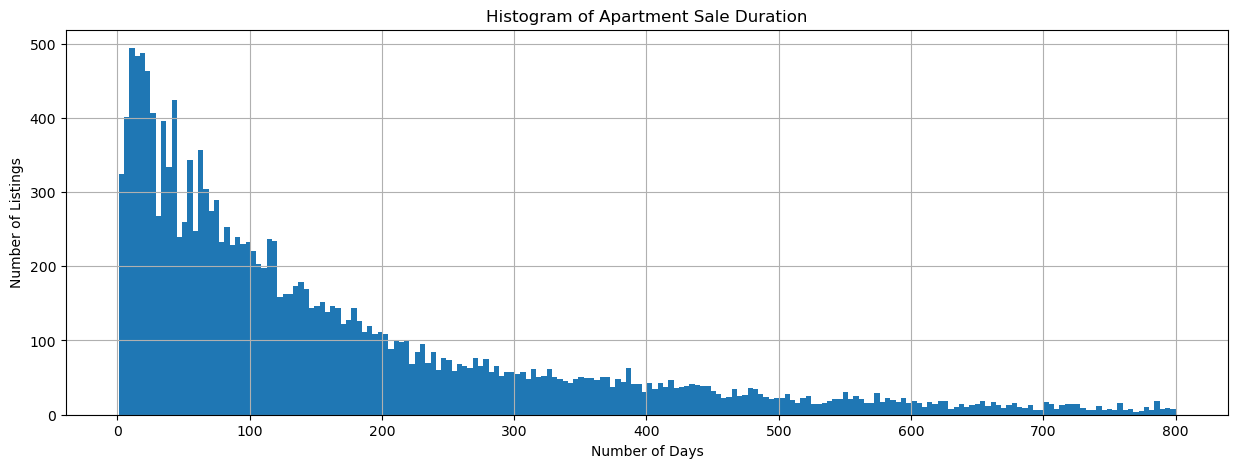

In [135]:
# Plotting a histogram for the filtered data
filtered_data['days_exposition'].hist(bins=200, figsize=(15, 5))
plt.title('Histogram of Apartment Sale Duration')
plt.xlabel('Number of Days')
plt.ylabel('Number of Listings')
plt.show()

**Description of Results**

During the outlier handling stage, peaks were identified at values 0, 7, 30, 45, 60, and 90. These were temporarily filtered out for calculations.

The average listing exposure time is approximately 167 days (5.5 months).

The median sale duration (107 days) indicates that most apartments are sold within about 3.5 to 4 months.

Sales can be considered fast if they take less than 43 days (25th percentile), and unusually long if the sale time exceeds 232 days (75th percentile).

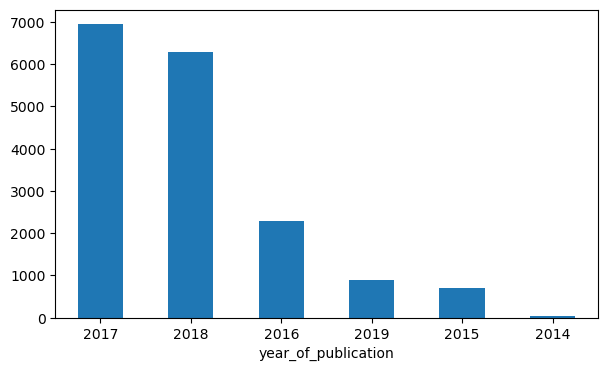

In [136]:
# Plotting the distribution of the number of announcements by year
filtered_data['year_of_publication'].value_counts().plot(kind='bar', figsize=(7, 4), rot=0);

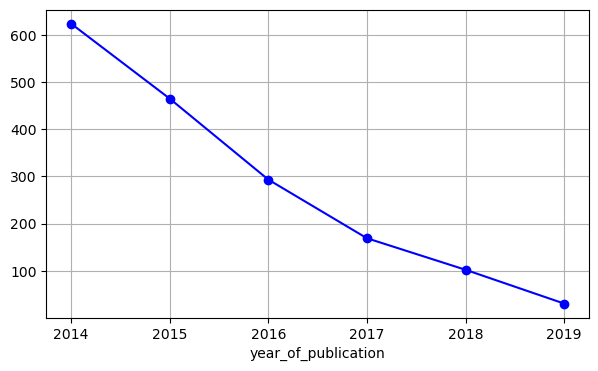

In [137]:
# Grouping data by year of publication and calculating the average number of days to sell
average_days_by_year = filtered_data.groupby('year_of_publication')['days_exposition'].mean()

# Plotting the change in average sale duration by year
average_days_by_year.plot(kind='line', figsize=(7, 4), marker='o', linestyle='-', color='b', grid=True);


There is a clear trend of decreasing average property sale duration from 2014 to 2018. This may indicate broader access to information through the internet.

The unusually low value for 2019 should not be taken as indicative, since the `'days_exposition'` column contains a large number of missing values (as many listings are still active).

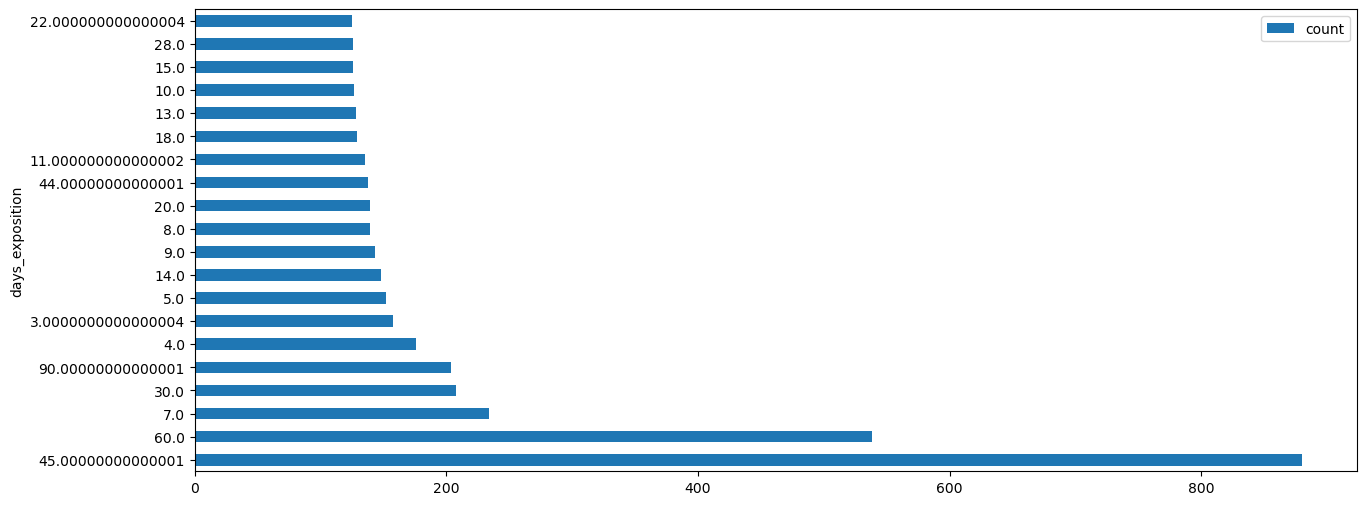

In [138]:
# check
# Modes in the raw data
     
df_check['days_exposition'].value_counts().to_frame().head(20).plot(kind = 'barh', figsize = (15,6), rot = 0);

#### Identifying the factors that have the greatest impact on the total property price

In [139]:
data[['last_price', 'total_area', 'living_area', 'kitchen_area', 
      'rooms', 'floor', 'ceiling_height']].corr()

,last_price,total_area,living_area,kitchen_area,rooms,floor,ceiling_height
last_price,1.000000,0.780977,0.679533,0.610124,0.498126,0.084893,0.114088
total_area,0.780977,1.000000,0.930612,0.590289,0.793393,-0.024098,0.103969
living_area,0.679533,0.930612,1.000000,0.376819,0.869131,-0.107097,0.090309
kitchen_area,0.610124,0.590289,0.376819,1.000000,0.246902,0.152364,0.083798
rooms,0.498126,0.793393,0.869131,0.246902,1.000000,-0.160775,0.051511
floor,0.084893,-0.024098,-0.107097,0.152364,-0.160775,1.000000,-0.010419
ceiling_height,0.114088,0.103969,0.090309,0.083798,0.051511,-0.010419,1.000000


Analyzing the presented Pearson correlation coefficients between apartment price and various parameters, we can draw the following conclusions about the relationship between price and these features:

##### Dependence of price on total, living, and kitchen area size

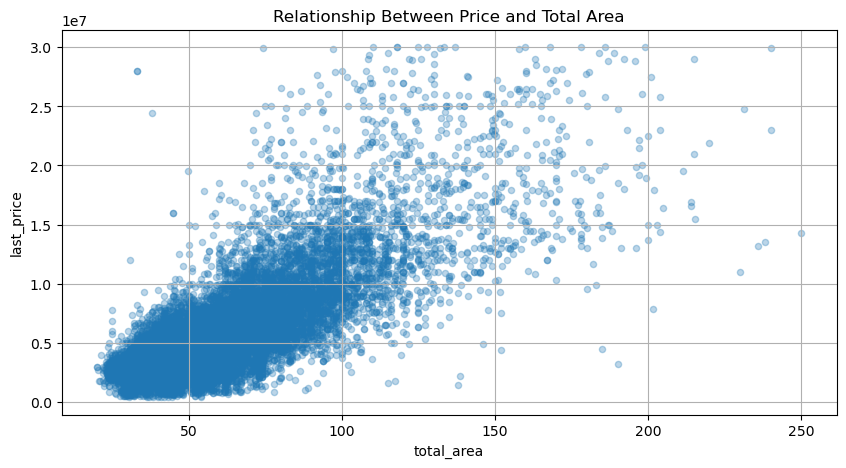

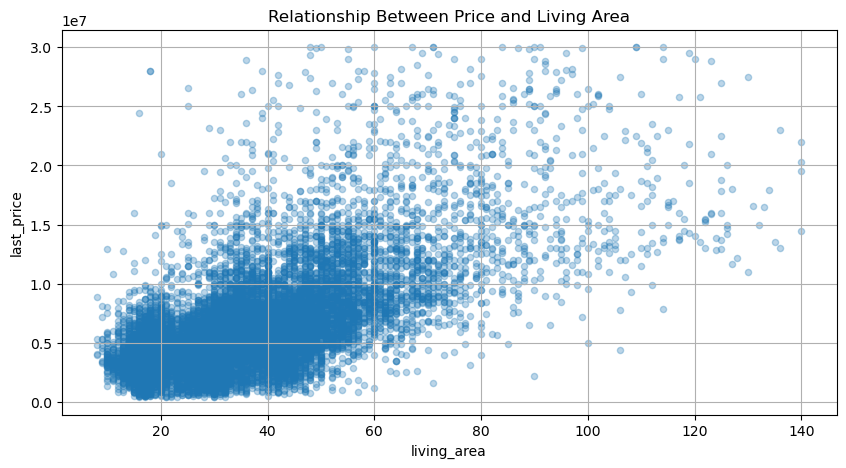

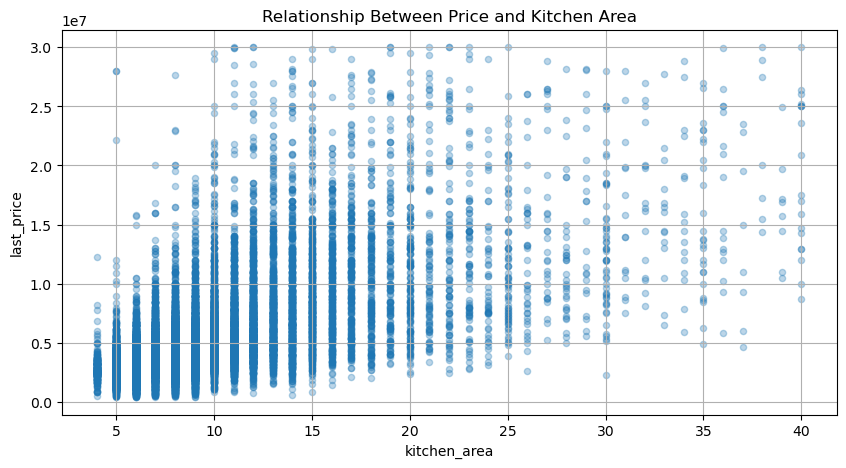

In [140]:
data.plot(x='total_area', y='last_price', kind='scatter', grid=True, figsize=(10, 5), alpha=0.3);
plt.title('Relationship Between Price and Total Area');

data.plot(x='living_area', y='last_price', kind='scatter', grid=True, figsize=(10, 5), alpha=0.3);
plt.title('Relationship Between Price and Living Area');

data.plot(x='kitchen_area', y='last_price', kind='scatter', grid=True, figsize=(10, 5), alpha=0.3);
plt.title('Relationship Between Price and Kitchen Area');


**Total Area:**  
This parameter has the highest correlation coefficient (0.78). In other words, the larger the apartment, the higher its price.

**Living Aa`):**  
With a correlation coefficient of 0.68, living area also has a strong influence on apartment price.

**Kitchearea`):**  
A correlation of 0.61 indicates a moderate relationship between price and kitchen size. Larger kitchens generally increase property value.

The scatter plots showing the relationships between area (total / living / kitchen) and price are quite similar, and several patterns can be observed:
As area increases, price tends to increase as well. The relationship between kitchen area and price is the weakest among the three.

There are some outlier points that deviate significantly from the main cluster of data. These may represent very expensive properties on the market—such as apartments in prestigious areas or those with unique features like luxury renovations or exclusive locations.

As the area increases, the spread of prices becomes wider. This suggests that for larger apartments, pricing factors become more diverse. For the largest properties, the price does not always increase proportionally. This could reflect limited demand for very large apartments or private mansions.

##### Dependence of price on number of rooms:


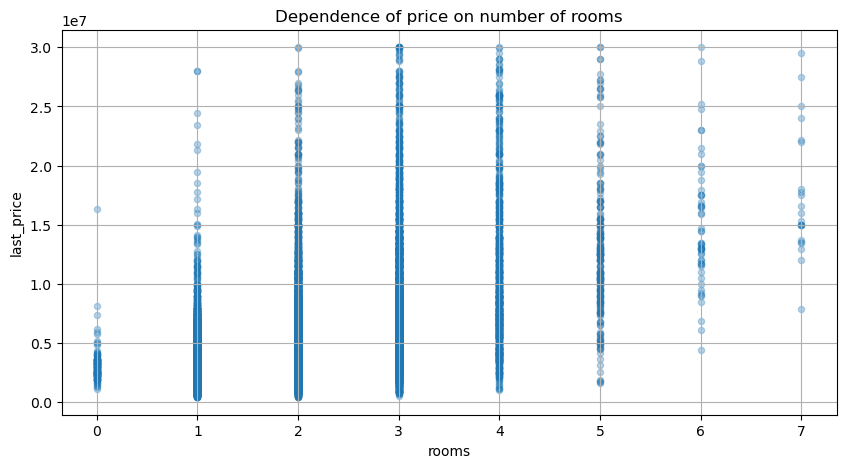

In [141]:
data.plot(x='rooms', y='last_price', kind='scatter', grid=True, figsize=(10, 5), alpha=0.3);
plt.title('Dependence of price on number of rooms');

A correlation coefficient of 0.5 indicates that the number of rooms also affects the price, but to a lesser extent compared to area. Apartments with more rooms are generally more expensive.

The plot shows a trend of increasing prices with a higher number of rooms. This is expected, as more rooms typically mean a larger total area.

Within each room count category, prices can vary significantly, indicating the influence of other factors such as location, property condition, and additional amenities.

##### Dependence of price on floor  
The lowest correlation coefficient among the considered parameters (area and number of rooms), at 0.08, indicates that price is weakly dependent on the floor on which the apartment is located.

Let's group the data by floor and calculate the median price per square meter.

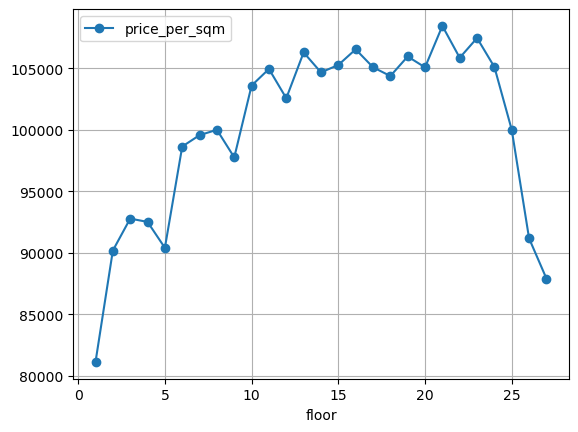

In [142]:
# grouping by floor and price per square meter
data.pivot_table(index='floor', values='price_per_sqm', aggfunc='median').reset_index().plot(
                      x='floor', grid=True, style='o-');

The price per square meter on the 1st floor is lower than on the floors above, and the price is also likely lower on the top floor.  
There are noticeable dips at the 5th, 9th, and 12th floors, which are likely due to standard building heights—these are probably also top floors in many buildings.

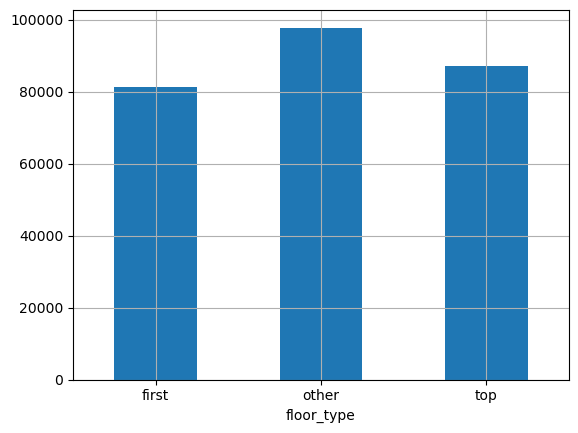

In [143]:
data.pivot_table(index='floor_type', values='price_per_sqm', aggfunc='median').reset_index().plot(
                      kind='bar', x='floor_type', y='price_per_sqm', grid=True, legend=False, rot=0);

**Conclusion:** Apartments on the first floor usually have the lowest price per square meter. Apartments on the top floor also tend to be cheaper than those on other floors.

##### Dependence of price on listing date (`day_of_week`, `month_of_publication`, `year_of_publication`):  
**Dependence of price on the year the listing was posted**

In [144]:
# First we count the number of ads for each year
data['year_of_publication'].value_counts().sort_index().to_frame()

,count
year_of_publication,
2014,62
2015,770
2016,2470
2017,7876
2018,8220
2019,2746


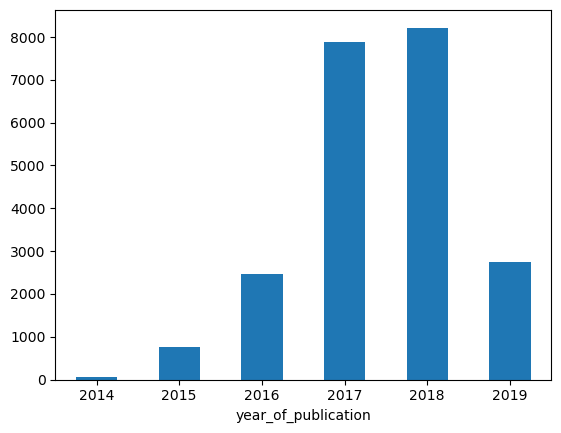

In [145]:
data['year_of_publication'].value_counts().sort_index().plot(kind='bar', rot=0);

Let's look at the number of listings by year. The number of listings increases each year (2019 is the current year, so it's not representative).  
The sharpest jump is from 2016 to 2017.  
We have only 62 listings from 2014 and 770 from 2015 — this may significantly impact the results.

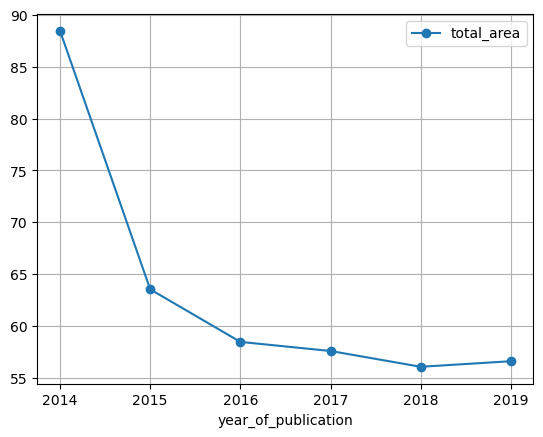

In [146]:
# grouping by year of listing and average apartment area
data.pivot_table(index='year_of_publication', values='total_area', 
                 aggfunc='mean').reset_index().plot(
                 x='year_of_publication', y='total_area', grid=True, style='o-');

Based on the chart, we can conclude that the average apartment size dropped sharply from 89 square meters in 2014 to 64 square meters in 2015, then decreased further to 59, with only minor fluctuations afterward.  
However, this is likely due to the small number of listings in 2014–2015.

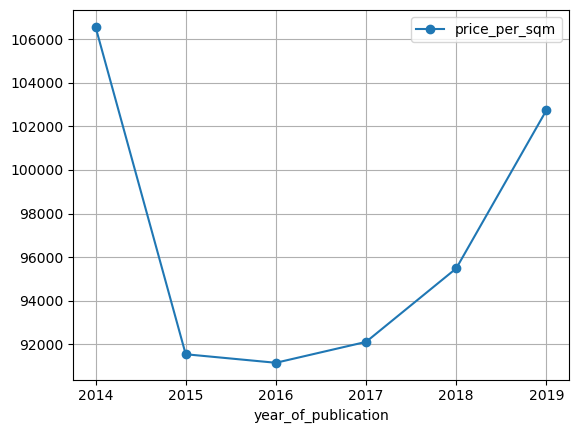

In [147]:
# grouping by year of listing and median price per square meter
data.pivot_table(index='year_of_publication', values='price_per_sqm', 
                 aggfunc='median').reset_index().plot(
                 x='year_of_publication', y='price_per_sqm', grid=True, style='o-');

This chart shows a sharp drop in the price per square meter in 2015.  
Starting from 2017, a gradual increase can be observed.  
The difference between the maximum and minimum price exceeds 15,000 rubles.

**Dependence of price on the month of listing**

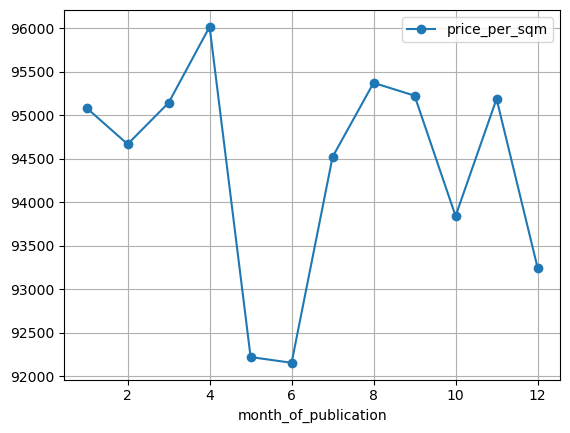

In [148]:
# grouping by month of listing and median price per square meter
data.pivot_table(index='month_of_publication', values='price_per_sqm', 
                 aggfunc='median').reset_index().plot(x='month_of_publication', 
                 y='price_per_sqm', grid=True, style='o-');

A noticeable price drop is observed in May and June, while the highest prices occur in April and August. This may be related to the vacation season.  
The spread between the maximum and minimum prices is relatively small — up to 4,000 rubles.

**Dependence of price on the day of listing**

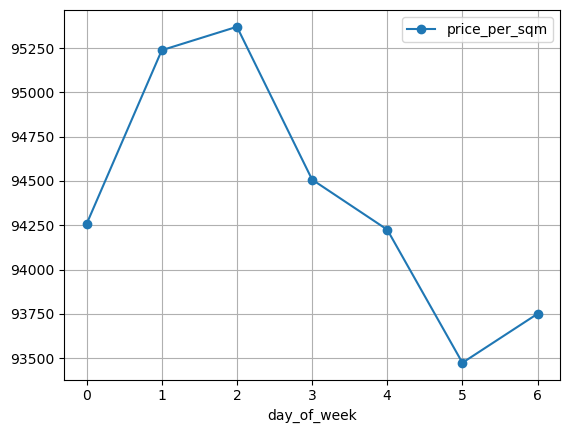

In [149]:
# grouping by day of listing and median price per square meter
data.pivot_table(index='day_of_week', values='price_per_sqm', 
                 aggfunc='median').reset_index().plot(x='day_of_week', 
                y='price_per_sqm', grid=True, style='o-');

The highest price per square meter occurs on Wednesday, while the lowest is on Saturday and Sunday.  
The difference is not significant — less than 2,000 rubles.

**Conclusion:**  
The year of listing has the greatest influence on the price per square meter. In 2015, prices dropped sharply, reaching their lowest point in 2016, followed by a gradual increase. However, it's important to note that the number of listings in 2014–2015 is significantly lower than in other years.  
The average apartment size also dropped sharply from 2014 to 2016, stabilizing at around 59 sq.m., with only minor fluctuations afterward. This is likely due to the small number of listings in 2014–2015.

There is a noticeable seasonality: prices peak in April and August, which may be linked to increased buyer activity after New Year and during the summer vacation season. A decline is observed in May and June, likely due to the holiday period.

There is also a weekly trend: the highest price per square meter is most often recorded on Wednesdays, while Fridays and Saturdays usually show the lowest values.

#### Selection of the 10 localities with the highest number of listings

In [150]:
# Create a list of the ten localities with the highest number of listings
top_10 = data.pivot_table(index='locality_name', values='first_day_exposition', 
                          aggfunc='count').sort_values(by='first_day_exposition', 
                                                       ascending=False).head(10)
top_10.columns=['number_of_ads']
top_10.reset_index()

,locality_name,number_of_ads
0,Санкт-Петербург,14633
1,Мурино,546
2,Кудрово,450
3,Шушары,426
4,Всеволожск,379
5,Пушкин,346
6,Колпино,332
7,Парголово,321
8,Гатчина,269
9,Выборг,205


In [151]:
# Calculate the average price per square meter for the localities in the generated list
top_10['cost_per_meter_mean'] = data.pivot_table(index='locality_name', values='price_per_sqm', aggfunc='mean').round(2)
top_10s = top_10.sort_values(by='cost_per_meter_mean', ascending=False).reset_index()
top_10s

,locality_name,number_of_ads,cost_per_meter_mean
0,Санкт-Петербург,14633,110232.78
1,Пушкин,346,102769.26
2,Кудрово,450,95250.88
3,Парголово,321,90162.39
4,Мурино,546,85922.97
5,Шушары,426,78202.42
6,Колпино,332,75180.83
7,Гатчина,269,69135.50
8,Всеволожск,379,68901.14
9,Выборг,205,58603.93


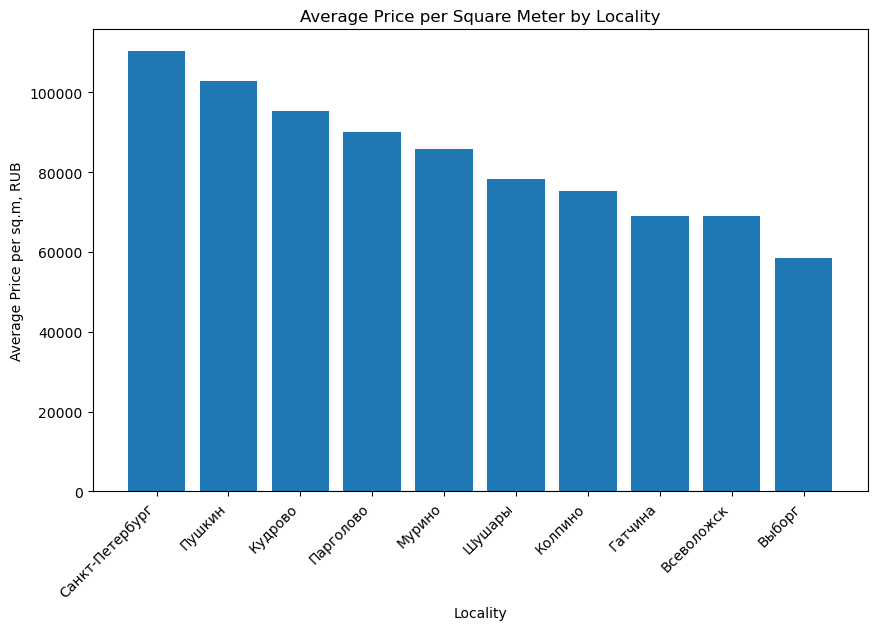

In [152]:
# Create a bar chart to visually show the difference in average price per square meter
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_10s['locality_name'], top_10s['cost_per_meter_mean'])
ax.set_title('Average Price per Square Meter by Locality')
ax.set_xlabel('Locality')
ax.set_ylabel('Average Price per sq.m, RUB')
ax.set_xticks(range(len(top_10s['locality_name'])))
ax.set_xticklabels(top_10s['locality_name'], rotation=45, ha='right')

plt.show()


**Conclusion:**  
Saint Petersburg leads in housing prices among the localities with the highest number of listings, with an average price per square meter of 110,232.78 rubles. This confirms the city’s status as a major economic and cultural center.

Pushkin, Kudrovo, Pargolovo, and Murino also show high housing costs. These areas are characterized by active construction and infrastructure development.

Vsevolozhsk and Vyborg have the lowest average price per square meter among the top 10 localities analyzed. Despite their proximity to major cities, these areas may have less developed infrastructure or other unfavorable factors.

#### Dependence of price on distance to the city center (St. Petersburg)  
We filter out apartments located in Saint Petersburg using the `locality_name` column and calculate their average price at different distances from the city center.

In [153]:
# Select apartments located in Saint Petersburg
spb_data = data[data['locality_name'] == 'Санкт-Петербург']

# Calculate the average price for each kilometer from the city center
avg_price_per_km = spb_data.groupby('distance_to_center_km')['last_price'].mean()
avg_price_per_km.to_frame()


,last_price
distance_to_center_km,
0.0,1.131867e+07
1.0,1.177555e+07
2.0,1.078251e+07
3.0,9.618393e+06
4.0,1.013030e+07
5.0,1.062732e+07
6.0,9.438792e+06
7.0,9.156810e+06
8.0,8.563015e+06


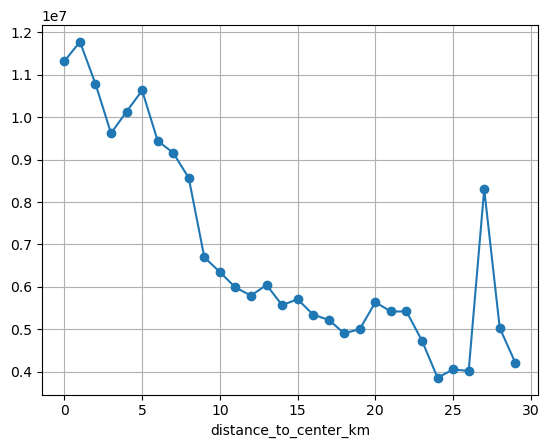

In [154]:
avg_price_per_km.plot(style='o-', grid=True);

In [155]:
spb_data.groupby('distance_to_center_km').size().sort_index().to_frame()

,0
distance_to_center_km,
0.0,15
1.0,155
2.0,248
3.0,311
4.0,600
5.0,774
6.0,512
7.0,356
8.0,547


In [156]:
# Check the listings located 27 km from the city center
spb_data[spb_data['distance_to_center_km'] == 27]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around_3000,ponds_nearest,days_exposition,distance_to_center_km,price_per_sqm,day_of_week,month_of_publication,year_of_publication,floor_type
696,13,14350000.0,74.0,2017-11-28,2,3.3,5,30,3,False,...,1496.0,0,NaN,128,27.0,193918.92,1,11,2017,other
5627,6,2250000.0,32.0,2018-02-27,1,2.6,2,16,2,False,...,NaN,0,NaN,178,27.0,70312.50,1,2,2018,top


The reason for the outlier at the 27th kilometer is the small number of listings (2), one of which is an apartment with an unusually high price. Most likely, it is a business-class property.

In [157]:
# Check the number of apartments of different floor types at 3 km and 5 km
filtered_spb_data = spb_data[spb_data['distance_to_center_km'].isin([1, 2, 3, 4, 5, 6])].groupby(
    ['distance_to_center_km', 'floor_type']).size().unstack()

# Calculate the total number of listings per distance
filtered_spb_data['total'] = (
    filtered_spb_data['other'] + filtered_spb_data['first'] + filtered_spb_data['top']
)

# Now calculate the percentage share of each floor category
filtered_spb_data['share_other'] = ((filtered_spb_data['other'] / filtered_spb_data['total']) * 100).round(2)
filtered_spb_data['share_first'] = ((filtered_spb_data['first'] / filtered_spb_data['total']) * 100).round(2)
filtered_spb_data['share_top'] = ((filtered_spb_data['top'] / filtered_spb_data['total']) * 100).round(2)

filtered_spb_data


floor_type,first,other,top,total,share_other,share_first,share_top
distance_to_center_km,,,,,,,
1.0,21,99,35,155,63.87,13.55,22.58
2.0,41,141,66,248,56.85,16.53,26.61
3.0,51,189,71,311,60.77,16.40,22.83
4.0,75,425,100,600,70.83,12.50,16.67
5.0,74,581,119,774,75.06,9.56,15.37
6.0,60,380,72,512,74.22,11.72,14.06


The reason for the peak at the 5th kilometer is the lowest share of apartments on the first floors.  
The reason for the dip at the 3rd kilometer is a higher share of apartments on the first and top floors.

Here, the results are as expected: the highest property prices are observed at a distance of 0 km from the city center—directly in the heart of the city—where the average price is approximately 11,318,670 rubles. This supports the general principle that housing in central urban areas tends to be the most expensive due to high demand, developed infrastructure, and historical value.

As the distance from the center increases, there is a noticeable trend of declining property prices. For example, just 1 km away, the average price drops to about 21,206,720 rubles, and by 9 km, it decreases to around 6,962,379 rubles. There is a sharp drop in average price between the 7th kilometer (14,775,150 rubles), the 8th kilometer (9,969,961 rubles), and the 9th kilometer (6,962,379 rubles).

Between 4–6 km from the center, there is a slight increase in average price compared to the 3rd kilometer. This may be due to specific location features or the presence of premium real estate with good infrastructure in those areas.

**Price spike at 27 km:**  
There is an unexpected price jump at a distance of 27 km from the center, reaching approximately 8,300,000 rubles. This may be explained by the presence of business-class properties or historically valuable real estate in that area.

**Conclusion:**  
Overall, the data confirms the general rule that the farther from the city center, the lower the average property price—although there are a few exceptions at certain distances.

### Overall Conclusion

#### Data Preprocessing: Issues Identified and Their Resolutions

During the data preprocessing stage, the following key issues were identified:

**Missing Values Detected in the Columns:**

- **`balcony` (number of balconies), `parks_around3000`, `ponds_around3000`** (number of parks and water bodies within a 3 km radius):  
  _Solution_: Missing values were interpreted as the absence of balconies, parks, or water bodies in the specified radius and were replaced with `0`.

- **`ceiling_height` (ceiling height):**  
  _Solution_: Filled with the median value for each kilometer in Saint Petersburg. Other missing values were filled with the overall median.

- **`airports_nearest`, `cityCenters_nearest`, `parks_nearest`, `ponds_nearest`**  
  (distances to important landmarks and their counts):  
  _Solution_: Missing values were left as they are, since filling them with the median or mean might distort the results.

- **`living_area` (living area) and `kitchen_area` (kitchen area):**  
  _Solution_: Filled with synthetic values.

- **`floors_total` (total number of floors in the building):**  
  _Solution_: Rows with missing values were removed, as they most likely occurred due to the lack of precise data.

- **`is_apartment` (whether the property is an apartment):**  
  _Solution_: A large number of missing values were replaced with `False`, as sellers likely do not fill in this parameter.

- **`locality_name` (name of the locality):**  
  _Solution_: Rows with missing values were removed, since their proportion is insignificant (`49` records). Possible reasons include technical errors or properties located outside populated areas.

- **`days_exposition` (number of days the listing was active):**  
  _Solution_: Missing values were left as is, as the possible reasons for their occurrence are:  
  1. The listings are still active.  
  2. Removal of the listing without a recorded date.  
  3. Technical errors.

**Artifacts (Anomalies):**

From the analysis, rare values and errors in data entry were excluded:

- **`rooms`** (more than `8` rooms)
- **`total_area`** (less than `20` m² or more than `250` m²)
- **`days_exposition`** (more than `800` days)
- **`last_price`** (less than `300,000` RUB or more than `30,000,000` RUB)
- **`living_area`** (less than `8` m² or more than `140` m²)
- **`kitchen_area`** (less than `4` m² or more than `40` m²)
- **`floors`** (floor numbers above the `27th`)
- **`floors_total`** (more than `40` floors)
- **`ceiling_height`** (less than `2.3` m or more than `5` m)

The removed rows constitute about **6.5%** of the entire dataset.

**Implicit Duplicates in Locality Names:** 

- Various representations of the same localities were identified.  
  _Solution_: Extra words were removed from the names.

**New Columns Added:** 
- Price per square meter (`cost_per_meter`)
- Day of the week of the listing (`day_of_week`)
- Month of the listing (`month`)
- Year of the listing (`year`)
- Distance to the city center in kilometers (`distance_to_center_km`)

---

#### Answers to the Project Goals:

**Influence of Parameters on Apartment Price**

**Pearson Correlation Coefficient between Price and Parameters:**

| Parameter                          | Correlation Coefficient |
|------------------------------------|-------------------------|
| Total Area (`total_area`)          | **0.78**                |
| Living Area (`living_area`)        | **0.68**                |
| Kitchen Area (`kitchen_area`)      | **0.61**                |
| Number of Rooms (`rooms`)          | **0.5**                 |
| Ceiling Height (`ceiling_height`)  | **0.1**                 |
| Floor (`floor`)                    | **0.08**                |

- **Apartment area** is the primary factor affecting the price.
- **Kitchen area** also influences the price, but less than total or living area.
- **Number of rooms** is correlated with total area, so its impact is predictable.
- **Ceiling height** and **floor** have a weak influence.

**Influence of the Listing Date:**
- The year of publication **has an impact**.
- Seasonality: **Prices peak in April and August**, with a dip in May and June.
- Days of the week: **Wednesday is the most expensive day**, while **Friday and Saturday are the cheapest**.

---

**Average Price per Square Meter by Locality**

| Locality         | Average Price per sq.m (RUB) |
|------------------|-------------------------|
| **Санкт-Петербург** | **110 232** |
| Пушкин | 102 543 |
| Кудрово | 97 345 |
| Парголово | 92 810 |
| Мурино | 90 567 |
| **Всеволожск** | **68 901** |
| **Выборг** | **58 604** |


**Conclusion:**  
- **Санкт-Петербург** is the leader in housing prices.  
- **Всеволожск and Выборг** are the most affordable.

---

**Dependence of Price on Distance from the Center of Saint Petersburg**

| Distance from Center | Average Apartment Price (RUB) |
|----------------------|-------------------------------|
| 0 km                 | **11,318,670**                |
| 9 km                 | 6,695,526                     |
| 29 km                | 4,210,000                     |

**Conclusion:** **The farther from the center, the lower the price.**

---

#### Recommendations for the Client:

**1. Improve Data Quality**
- Make the locality mandatory.
- Automatically assign `0` if `balcony`, `parks_around3000`, or `ponds_around3000` is not specified.
- Automatically assign `False` if `is_apartment` is not specified.

**2. Enhance Labeling**
- Check localities with missing values in `distance_to_center` and `airports_nearest`:  
  _Murino, Kudrovo, Vsevolozhsk, Gatchina, Vyborg, Novoye Devyatkino, Sertolovo, Kirishi, Bugry, Volkhov, etc._
- Add mapping for parks and ponds for all localities with missing data.

**3. Implement an Anomaly Detection System**
- Automatically check if a listing contains **unrealistic values** (e.g., 1 m² for 1,000 RUB).
- Alert moderators about potential fraudulent listings.

**Conclusion:**  
Correcting the data and automating its processing will help **increase the accuracy of the real estate market analysis**.

### Bonus

In [158]:
# check
import seaborn as sns
import matplotlib.pyplot as plt

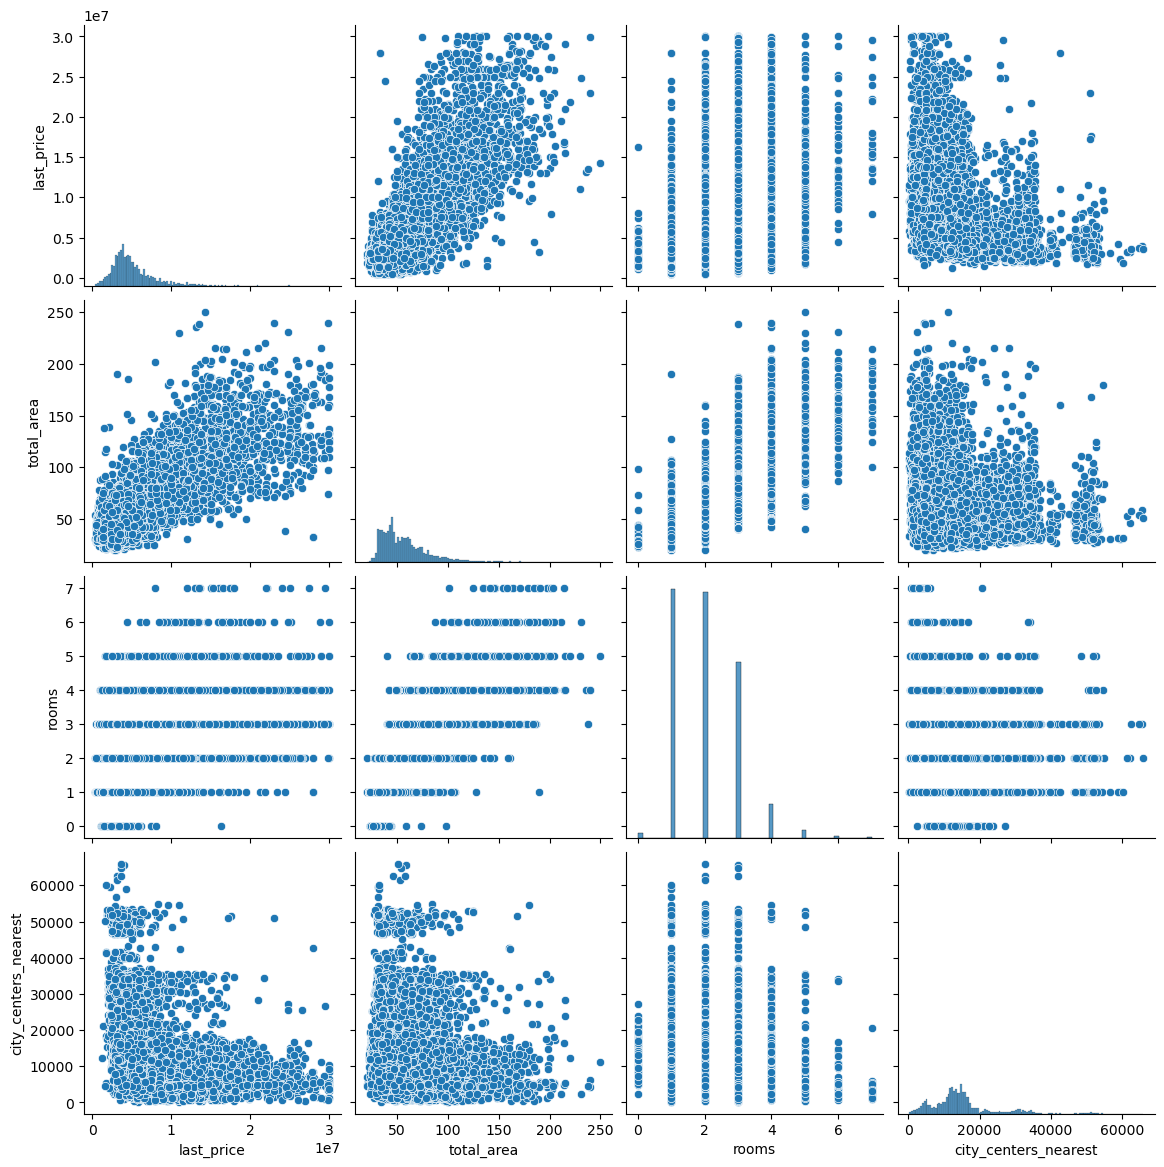

In [159]:
# check
sns.pairplot(data[['last_price', 'total_area', 'rooms', 'city_centers_nearest']])
plt.gcf().set_size_inches(12,12);


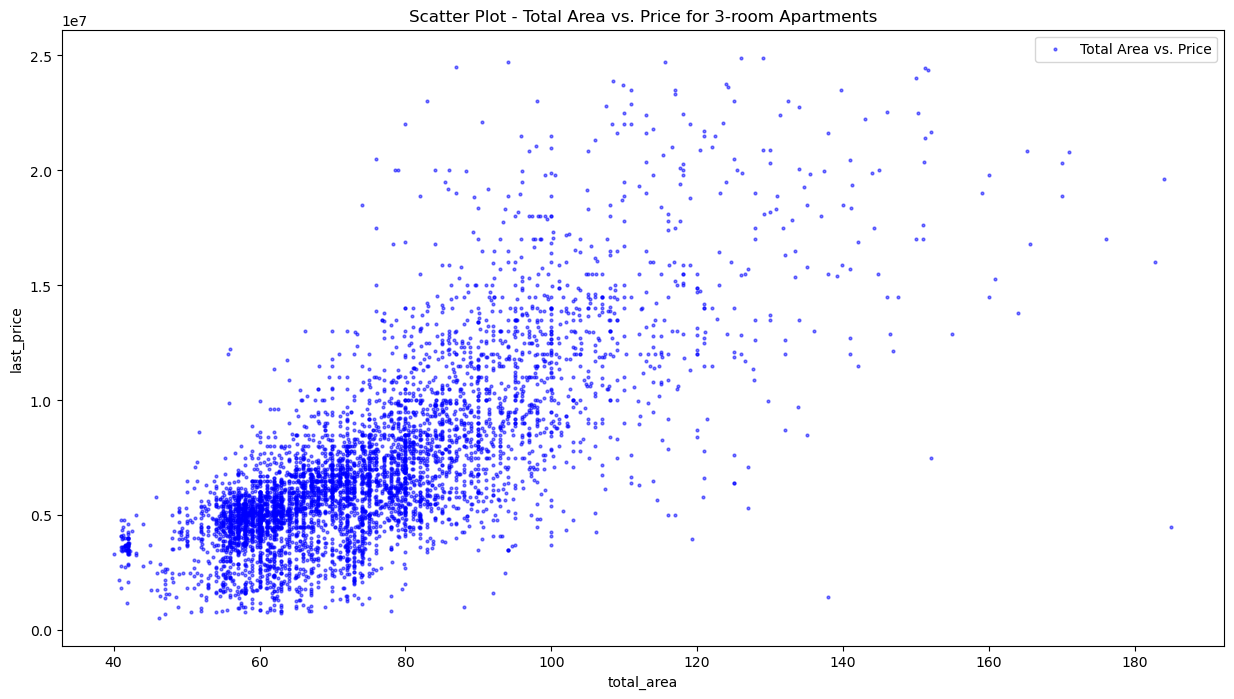

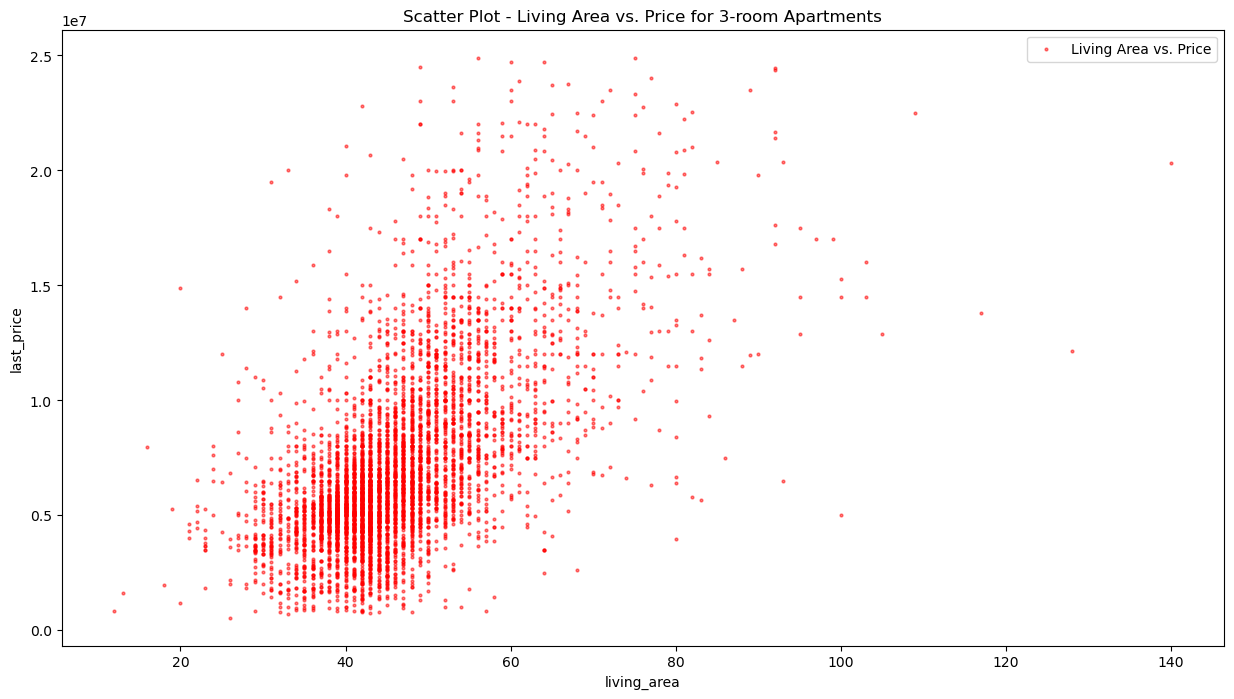

In [160]:
# Scatter plot - Total Area vs. Price for 3-room Apartments
ax1 = data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(
    kind='scatter', y='last_price', x='total_area', alpha=0.5, figsize=(15,8), c='b', s=4)
ax1.set_title('Scatter Plot - Total Area vs. Price for 3-room Apartments')
ax1.legend(['Total Area vs. Price'])
plt.show()

# Scatter plot - Living Area vs. Price for 3-room Apartments
ax2 = data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(
    kind='scatter', y='last_price', x='living_area', alpha=0.5, figsize=(15,8), c='r', s=4)
ax2.set_title('Scatter Plot - Living Area vs. Price for 3-room Apartments')
ax2.legend(['Living Area vs. Price'])
plt.show()


In [161]:
# check TOP-10
# Methods of grouping and sorting information

(
    data
    .groupby('locality_name')['last_price']
    .agg({'count', 'mean'})
    .sort_values(by='count', ascending=False)
    .head(10)
    
).sort_values(by='mean', ascending=False).style.format("{:,.0f}")

# .plot(y='mean', kind='bar')
# Note: style and plot do not work together

,mean,count
locality_name,,
Санкт-Петербург,"6,725,124","14,633"
Пушкин,"6,075,203",346
Парголово,"4,496,793",321
Кудрово,"4,400,106",450
Шушары,"4,140,580",426
Колпино,"3,856,266",332
Всеволожск,"3,838,109",379
Мурино,"3,712,562",546
Гатчина,"3,541,648",269
